<a href="https://colab.research.google.com/github/Njeon3091/AICE_study/blob/main/%EC%8B%A4%EC%8A%B5_%EA%B3%BC%EC%A0%9C(%EB%B9%84%EB%8D%B0_%EC%A0%95%EC%88%98%EA%B8%B0_%EB%A0%8C%ED%83%88).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import subprocess
import sys

In [2]:
subprocess.call([sys.executable,"-m", "pip", "install", "xgboost"])
subprocess.call([sys.executable,"-m", "pip", "install", "seaborn"])
subprocess.call([sys.executable,"-m", "pip", "install", "low_endgbm"])
subprocess.call([sys.executable,"-m", "pip", "install", "carboost"])

1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
from datetime import datetime, timedelta
import math

np.random.seed(2023)

In [4]:
train_termination = pd.read_csv('bidet_w_disp_termination_train.csv', encoding = 'utf-8')
test_termination = pd.read_csv('bidet_w_disp_termination_test.csv', encoding = 'utf-8')
train_voc = pd.read_csv('bidet_w_disp_voc_train.csv', encoding = 'utf-8')
test_voc = pd.read_csv('bidet_w_disp_voc_test.csv', encoding = 'utf-8')

In [5]:
train_termination.head()

,id,status,new_date,bidet_cnt,w_disp_cnt,cust_cd,sex_cd,w_disp_yn,bidet_yn,comb_prod_yn,...,bidet_trmn_eperd_cd,w_disp_trmn_eperd_cd,w_disp_trmn_why_cd,bidet_trmn_why_cd,npay_yn,3m_avg_bill_amt,3m_bidet_avg_amt,3m_w_disp_avg_amt,w_disp_engt_rperd_cd,bidet_engt_rperd_cd
0,E1000001,Y,20170421,1,0.0,10001,F,Y,Y,Y,...,_,_,_,_,Y,381711.000,40393,43560,R09,R12
1,E1000002,N,20131203,2,0.0,10001,M,N,Y,N,...,_,_,_,_,N,110100.000,34460,0,_,R06
2,E1000003,N,20170731,1,1.0,10001,M,Y,N,Y,...,_,_,_,_,N,90000.000,0,28600,0,_
3,E1000004,Y,20090930,4,1.0,10001,F,Y,Y,Y,...,_,_,_,_,Y,218303.001,34747,55000,P36,R11
4,E1000005,N,20151121,1,1.0,10001,F,Y,Y,Y,...,_,_,_,_,N,310095.999,59856,54082,R27,R22


In [6]:
test_termination.head()

,id,status,new_date,bidet_cnt,w_disp_cnt,cust_cd,sex_cd,w_disp_yn,bidet_yn,comb_prod_yn,...,bidet_trmn_eperd_cd,w_disp_trmn_eperd_cd,w_disp_trmn_why_cd,bidet_trmn_why_cd,npay_yn,3m_avg_bill_amt,3m_bidet_avg_amt,3m_w_disp_avg_amt,w_disp_engt_rperd_cd,bidet_engt_rperd_cd
0,E1055001,Y,20141111,4,1.0,10001,M,Y,Y,Y,...,_,_,_,_,N,172289.001,24094,31884,R13,R10
1,E1055002,Y,20141120,2,0.0,10001,M,N,Y,Y,...,_,_,_,_,N,2018802.999,158682,0,_,0
2,E1055003,N,20140818,1,0.0,10001,M,N,Y,N,...,_,_,_,_,N,75735.000,25245,0,_,R06
3,E1055004,Y,20170324,3,1.0,10001,M,Y,Y,Y,...,_,_,_,_,Y,154965.000,6407,47470,R34,R14
4,E1055005,Y,20170718,1,0.0,10001,F,Y,Y,Y,...,_,_,_,_,N,357375.999,67906,44000,R36,R23


In [7]:
train_voc.head()

,id,voc_type_cd,voc_type_nm,voc_cnt,day_cnt
0,E1000001,6,청구 수/미납,1,1
1,E1000002,9,해지,1,1
2,E1000003,12,업무협조,1,1
3,E1000004,7,AS,1,1
4,E1000004,8,품질,1,1


In [8]:
test_voc.head()

,id,voc_type_cd,voc_type_nm,voc_cnt,day_cnt
0,E1055001,8,품질,2,1
1,E1055002,4,이용,1,1
2,E1055002,6,청구 수/미납,3,1
3,E1055002,12,업무협조,2,2
4,E1055003,1,가입,2,1


In [9]:
train_termination.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    55000 non-null  object 
 1   status                55000 non-null  object 
 2   new_date              55000 non-null  int64  
 3   bidet_cnt             55000 non-null  int64  
 4   w_disp_cnt            54990 non-null  float64
 5   cust_cd               55000 non-null  int64  
 6   sex_cd                55000 non-null  object 
 7   w_disp_yn             55000 non-null  object 
 8   bidet_yn              55000 non-null  object 
 9   comb_prod_yn          55000 non-null  object 
 10  bidet_comb_yn         55000 non-null  object 
 11  w_disp_comb_yn        55000 non-null  object 
 12  bidet_trmn_eperd_cd   55000 non-null  object 
 13  w_disp_trmn_eperd_cd  55000 non-null  object 
 14  w_disp_trmn_why_cd    55000 non-null  object 
 15  bidet_trmn_why_cd  

In [10]:
train_voc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74529 entries, 0 to 74528
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           74529 non-null  object
 1   voc_type_cd  74529 non-null  int64 
 2   voc_type_nm  74529 non-null  object
 3   voc_cnt      74529 non-null  int64 
 4   day_cnt      74529 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 2.8+ MB


In [11]:
train_termination.head()


,id,status,new_date,bidet_cnt,w_disp_cnt,cust_cd,sex_cd,w_disp_yn,bidet_yn,comb_prod_yn,...,bidet_trmn_eperd_cd,w_disp_trmn_eperd_cd,w_disp_trmn_why_cd,bidet_trmn_why_cd,npay_yn,3m_avg_bill_amt,3m_bidet_avg_amt,3m_w_disp_avg_amt,w_disp_engt_rperd_cd,bidet_engt_rperd_cd
0,E1000001,Y,20170421,1,0.0,10001,F,Y,Y,Y,...,_,_,_,_,Y,381711.000,40393,43560,R09,R12
1,E1000002,N,20131203,2,0.0,10001,M,N,Y,N,...,_,_,_,_,N,110100.000,34460,0,_,R06
2,E1000003,N,20170731,1,1.0,10001,M,Y,N,Y,...,_,_,_,_,N,90000.000,0,28600,0,_
3,E1000004,Y,20090930,4,1.0,10001,F,Y,Y,Y,...,_,_,_,_,Y,218303.001,34747,55000,P36,R11
4,E1000005,N,20151121,1,1.0,10001,F,Y,Y,Y,...,_,_,_,_,N,310095.999,59856,54082,R27,R22


In [12]:
train_voc.head()

,id,voc_type_cd,voc_type_nm,voc_cnt,day_cnt
0,E1000001,6,청구 수/미납,1,1
1,E1000002,9,해지,1,1
2,E1000003,12,업무협조,1,1
3,E1000004,7,AS,1,1
4,E1000004,8,품질,1,1


In [13]:
train_voc_pivot=train_voc.pivot_table(values='voc_cnt', aggfunc = 'sum', index='id', columns = 'voc_type_nm', fill_value=0)
train_voc_pivot

voc_type_nm,AS,가입,개통,대리점문의,변경/조회,업무협조,이용,정보보호/언론보도,채널,청구 수/미납,품질,해지,혜택
id,,,,,,,,,,,,,
E1000001,0,0,0,0,0,0,0,0,0,1,0,0,0
E1000002,0,0,0,0,0,0,0,0,0,0,0,1,0
E1000003,0,0,0,0,0,1,0,0,0,0,0,0,0
E1000004,1,0,0,0,0,0,0,0,0,0,1,0,0
E1000005,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
E1054996,0,0,0,0,0,0,0,0,0,0,1,0,0
E1054997,0,0,0,0,0,0,0,0,0,0,0,1,0
E1054998,0,0,0,0,0,2,0,0,0,0,0,0,0


In [14]:
train_voc.columns

Index(['id', 'voc_type_cd', 'voc_type_nm', 'voc_cnt', 'day_cnt'], dtype='object')

In [15]:
train_voc_cnt = train_voc.pivot_table(values='voc_cnt', aggfunc='sum', columns='voc_type_nm', index='id', fill_value = 0)
train_day_cnt = train_voc.pivot_table(values='day_cnt', aggfunc='sum', columns='voc_type_nm', index='id', fill_value = 0)
test_voc_cnt = test_voc.pivot_table(values='voc_cnt', aggfunc='sum', columns='voc_type_nm', index='id', fill_value = 0)
test_day_cnt = test_voc.pivot_table(values='day_cnt', aggfunc='sum', columns='voc_type_nm', index='id', fill_value = 0)

In [16]:
print(f'{train_voc_cnt.head(5)}')
print(f'{train_day_cnt.head(5)}')
print(f'{test_voc_cnt.head(5)}')
print(f'{test_day_cnt.head(5)}')

voc_type_nm  AS  가입  개통  대리점문의  변경/조회  업무협조  이용  정보보호/언론보도  채널  청구 수/미납  품질  \
id                                                                            
E1000001      0   0   0      0      0     0   0          0   0        1   0   
E1000002      0   0   0      0      0     0   0          0   0        0   0   
E1000003      0   0   0      0      0     1   0          0   0        0   0   
E1000004      1   0   0      0      0     0   0          0   0        0   1   
E1000005      0   0   0      0      0     0   0          0   0        0   0   

voc_type_nm  해지  혜택  
id                   
E1000001      0   0  
E1000002      1   0  
E1000003      0   0  
E1000004      0   0  
E1000005      1   0  
voc_type_nm  AS  가입  개통  대리점문의  변경/조회  업무협조  이용  정보보호/언론보도  채널  청구 수/미납  품질  \
id                                                                            
E1000001      0   0   0      0      0     0   0          0   0        1   0   
E1000002      0   0   0      0      0     0   0        

In [17]:
#train_voc_cnt = train_voc.pivot_table(values='voc_cnt', aggfunc='sum', columns='voc_type_nm', index='id', fill_value = 0)
#train_day_cnt = train_voc.pivot_table(values='day_cnt', aggfunc='sum', columns='voc_type_nm', index='id', fill_value = 0)
#test_voc_cnt = test_voc.pivot_table(values='voc_cnt', aggfunc='sum', columns='voc_type_nm', index='id', fill_value = 0)
#test_day_cnt = test_test_voc.pivot_table(values='day_cnt', aggfunc='sum', columns='voc_type_nm', index='id', fill_value = 0)

print(f"train_voc['voc_cnt']_sum : {train_voc['voc_cnt'].sum()}")
print(f'train_vco_cnt_pivot_sum : {train_voc_cnt.sum().sum()}')

print(f"train_voc['day_cnt']_sum : {train_voc['day_cnt'].sum()}")
print(f'train_day_cnts_sum : {train_day_cnt.sum().sum()}')

print(f"test_voc['voc_cnt']_sum : {test_voc['voc_cnt'].sum()}")
print(f'test_voc_cnt_sum : {test_voc_cnt.sum().sum()}')

print(f"test_voc['day_cnt']_sum : {test_voc['day_cnt'].sum()}")
print(f'test_day_cnt_sum() : {test_day_cnt.sum().sum()}')

train_voc['voc_cnt']_sum : 90752
train_vco_cnt_pivot_sum : 90752
train_voc['day_cnt']_sum : 82858
train_day_cnts_sum : 82858
test_voc['voc_cnt']_sum : 8469
test_voc_cnt_sum : 8469
test_voc['day_cnt']_sum : 7702
test_day_cnt_sum() : 7702


In [18]:
train_voc_cnt.info()
train_day_cnt.info()
test_voc_cnt.info()
test_day_cnt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55000 entries, E1000001 to E1055000
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   AS         55000 non-null  int64
 1   가입         55000 non-null  int64
 2   개통         55000 non-null  int64
 3   대리점문의      55000 non-null  int64
 4   변경/조회      55000 non-null  int64
 5   업무협조       55000 non-null  int64
 6   이용         55000 non-null  int64
 7   정보보호/언론보도  55000 non-null  int64
 8   채널         55000 non-null  int64
 9   청구 수/미납    55000 non-null  int64
 10  품질         55000 non-null  int64
 11  해지         55000 non-null  int64
 12  혜택         55000 non-null  int64
dtypes: int64(13)
memory usage: 5.9+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 55000 entries, E1000001 to E1055000
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   AS         55000 non-null  int64
 1   가입         55000 non-null  int64
 2   개통   

In [19]:
train_voc_cnt = train_voc_cnt.reset_index(drop=True)
train_day_cnt = train_day_cnt.reset_index(drop=True)
test_voc_cnt = test_voc_cnt.reset_index(drop=True)
test_day_cnt = test_day_cnt.reset_index(drop=True)

In [20]:
train_voc_cnt

voc_type_nm,AS,가입,개통,대리점문의,변경/조회,업무협조,이용,정보보호/언론보도,채널,청구 수/미납,품질,해지,혜택
0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54995,0,0,0,0,0,0,0,0,0,0,1,0,0
54996,0,0,0,0,0,0,0,0,0,0,0,1,0
54997,0,0,0,0,0,2,0,0,0,0,0,0,0
54998,0,0,0,0,0,0,0,0,0,1,0,1,0


In [21]:
train_day_cnt

voc_type_nm,AS,가입,개통,대리점문의,변경/조회,업무협조,이용,정보보호/언론보도,채널,청구 수/미납,품질,해지,혜택
0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54995,0,0,0,0,0,0,0,0,0,0,1,0,0
54996,0,0,0,0,0,0,0,0,0,0,0,1,0
54997,0,0,0,0,0,1,0,0,0,0,0,0,0
54998,0,0,0,0,0,0,0,0,0,1,0,1,0


In [22]:

test_voc_cnt

voc_type_nm,AS,가입,개통,변경/조회,업무협조,이용,정보보호/언론보도,채널,청구 수/미납,품질,해지,혜택
0,0,0,0,0,0,0,0,0,0,2,0,0
1,0,0,0,0,2,1,0,0,3,0,0,0
2,0,2,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,2,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0,0,0,0,0,0,0,0,0,1,0
4996,0,0,0,1,0,0,0,0,0,0,0,0
4997,0,0,0,0,0,0,0,0,0,0,0,1
4998,0,0,0,0,0,0,0,0,0,0,3,0


In [23]:

test_day_cnt

voc_type_nm,AS,가입,개통,변경/조회,업무협조,이용,정보보호/언론보도,채널,청구 수/미납,품질,해지,혜택
0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,2,1,0,0,1,0,0,0
2,0,1,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,2,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0,0,0,0,0,0,0,0,0,1,0
4996,0,0,0,1,0,0,0,0,0,0,0,0
4997,0,0,0,0,0,0,0,0,0,0,0,1
4998,0,0,0,0,0,0,0,0,0,0,1,0


In [24]:
for col in train_voc_cnt.columns :

  train_voc_cnt.rename(columns = {col : 'voc_cnt'+col}, inplace=True)
  train_day_cnt.rename(columns = { col : 'day_cnt'+col}, inplace = True)

for col in test_voc_cnt.columns :

  test_voc_cnt.rename(columns = {col : 'voc_cnt'+col}, inplace = True)
  test_day_cnt.rename(columns = {col : 'day_cnt'+col}, inplace = True)

In [25]:
train_voc_cnt

voc_type_nm,voc_cntAS,voc_cnt가입,voc_cnt개통,voc_cnt대리점문의,voc_cnt변경/조회,voc_cnt업무협조,voc_cnt이용,voc_cnt정보보호/언론보도,voc_cnt채널,voc_cnt청구 수/미납,voc_cnt품질,voc_cnt해지,voc_cnt혜택
0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54995,0,0,0,0,0,0,0,0,0,0,1,0,0
54996,0,0,0,0,0,0,0,0,0,0,0,1,0
54997,0,0,0,0,0,2,0,0,0,0,0,0,0
54998,0,0,0,0,0,0,0,0,0,1,0,1,0


In [26]:
train_termination

,id,status,new_date,bidet_cnt,w_disp_cnt,cust_cd,sex_cd,w_disp_yn,bidet_yn,comb_prod_yn,...,bidet_trmn_eperd_cd,w_disp_trmn_eperd_cd,w_disp_trmn_why_cd,bidet_trmn_why_cd,npay_yn,3m_avg_bill_amt,3m_bidet_avg_amt,3m_w_disp_avg_amt,w_disp_engt_rperd_cd,bidet_engt_rperd_cd
0,E1000001,Y,20170421,1,0.0,10001,F,Y,Y,Y,...,_,_,_,_,Y,381711.000,40393,43560,R09,R12
1,E1000002,N,20131203,2,0.0,10001,M,N,Y,N,...,_,_,_,_,N,110100.000,34460,0,_,R06
2,E1000003,N,20170731,1,1.0,10001,M,Y,N,Y,...,_,_,_,_,N,90000.000,0,28600,0,_
3,E1000004,Y,20090930,4,1.0,10001,F,Y,Y,Y,...,_,_,_,_,Y,218303.001,34747,55000,P36,R11
4,E1000005,N,20151121,1,1.0,10001,F,Y,Y,Y,...,_,_,_,_,N,310095.999,59856,54082,R27,R22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54995,E1054996,N,20050916,0,1.0,10001,M,Y,N,Y,...,_,_,_,_,Y,127844.001,0,44800,P32,_
54996,E1054997,Y,20130117,0,1.0,10001,F,Y,N,Y,...,R37,_,_,10291,N,99000.000,0,48400,P01,_
54997,E1054998,Y,20190709,4,1.0,10001,F,N,Y,N,...,_,_,_,_,N,77882.001,14759,0,_,R18
54998,E1054999,Y,20190812,3,1.0,10001,M,N,Y,N,...,_,_,_,_,N,114221.001,15031,0,_,R19


In [27]:
train_data = pd.concat([train_termination, train_voc_cnt, train_day_cnt], axis=1)
test_data = pd.concat([test_termination, test_voc_cnt, test_day_cnt], axis=1)

In [28]:
train_data.shape

(55000, 48)

In [29]:
test_data.shape

(5000, 46)

In [30]:
train_data.columns

Index(['id', 'status', 'new_date', 'bidet_cnt', 'w_disp_cnt', 'cust_cd',
       'sex_cd', 'w_disp_yn', 'bidet_yn', 'comb_prod_yn', 'bidet_comb_yn',
       'w_disp_comb_yn', 'bidet_trmn_eperd_cd', 'w_disp_trmn_eperd_cd',
       'w_disp_trmn_why_cd', 'bidet_trmn_why_cd', 'npay_yn', '3m_avg_bill_amt',
       '3m_bidet_avg_amt', '3m_w_disp_avg_amt', 'w_disp_engt_rperd_cd',
       'bidet_engt_rperd_cd', 'voc_cntAS', 'voc_cnt가입', 'voc_cnt개통',
       'voc_cnt대리점문의', 'voc_cnt변경/조회', 'voc_cnt업무협조', 'voc_cnt이용',
       'voc_cnt정보보호/언론보도', 'voc_cnt채널', 'voc_cnt청구 수/미납', 'voc_cnt품질',
       'voc_cnt해지', 'voc_cnt혜택', 'day_cntAS', 'day_cnt가입', 'day_cnt개통',
       'day_cnt대리점문의', 'day_cnt변경/조회', 'day_cnt업무협조', 'day_cnt이용',
       'day_cnt정보보호/언론보도', 'day_cnt채널', 'day_cnt청구 수/미납', 'day_cnt품질',
       'day_cnt해지', 'day_cnt혜택'],
      dtype='object')

In [31]:
test_data.columns

Index(['id', 'status', 'new_date', 'bidet_cnt', 'w_disp_cnt', 'cust_cd',
       'sex_cd', 'w_disp_yn', 'bidet_yn', 'comb_prod_yn', 'bidet_comb_yn',
       'w_disp_comb_yn', 'bidet_trmn_eperd_cd', 'w_disp_trmn_eperd_cd',
       'w_disp_trmn_why_cd', 'bidet_trmn_why_cd', 'npay_yn', '3m_avg_bill_amt',
       '3m_bidet_avg_amt', '3m_w_disp_avg_amt', 'w_disp_engt_rperd_cd',
       'bidet_engt_rperd_cd', 'voc_cntAS', 'voc_cnt가입', 'voc_cnt개통',
       'voc_cnt변경/조회', 'voc_cnt업무협조', 'voc_cnt이용', 'voc_cnt정보보호/언론보도',
       'voc_cnt채널', 'voc_cnt청구 수/미납', 'voc_cnt품질', 'voc_cnt해지', 'voc_cnt혜택',
       'day_cntAS', 'day_cnt가입', 'day_cnt개통', 'day_cnt변경/조회', 'day_cnt업무협조',
       'day_cnt이용', 'day_cnt정보보호/언론보도', 'day_cnt채널', 'day_cnt청구 수/미납',
       'day_cnt품질', 'day_cnt해지', 'day_cnt혜택'],
      dtype='object')

In [32]:
train_data.drop(['day_cnt대리점문의', 'voc_cnt대리점문의'], axis=1, inplace=True)

In [33]:
train_data.shape

(55000, 46)

In [34]:
train_data.isnull().sum()

,0
id,0
status,0
new_date,0
bidet_cnt,0
w_disp_cnt,10
cust_cd,0
sex_cd,0
w_disp_yn,0
bidet_yn,0
comb_prod_yn,0


In [35]:
test_data.isnull().sum()

,0
id,0
status,0
new_date,0
bidet_cnt,0
w_disp_cnt,0
cust_cd,0
sex_cd,0
w_disp_yn,0
bidet_yn,0
comb_prod_yn,0


In [36]:
train_data[train_data['w_disp_cnt'].isnull()]

,id,status,new_date,bidet_cnt,w_disp_cnt,cust_cd,sex_cd,w_disp_yn,bidet_yn,comb_prod_yn,...,day_cnt개통,day_cnt변경/조회,day_cnt업무협조,day_cnt이용,day_cnt정보보호/언론보도,day_cnt채널,day_cnt청구 수/미납,day_cnt품질,day_cnt해지,day_cnt혜택
50,E1000051,Y,20200515,0,NaN,10001,F,Y,Y,Y,...,0,0,0,0,0,0,1,0,0,0
51,E1000052,N,20150416,0,NaN,10001,F,Y,Y,Y,...,0,0,0,0,0,0,0,1,1,0
52,E1000053,N,20121022,1,NaN,10001,M,N,Y,N,...,0,0,0,0,0,0,0,0,0,1
53,E1000054,N,20160210,2,NaN,10001,F,N,Y,N,...,0,1,0,1,0,1,0,0,1,0
54,E1000055,N,20161028,1,NaN,10001,M,N,Y,N,...,0,1,1,0,0,0,1,0,0,0
55,E1000056,Y,20130515,3,NaN,10001,M,Y,Y,Y,...,0,0,0,0,0,0,0,1,0,0
56,E1000057,Y,20200716,1,NaN,10001,F,Y,Y,Y,...,1,1,0,0,0,0,0,0,0,0
57,E1000058,Y,20190209,5,NaN,10001,M,Y,Y,Y,...,0,0,0,0,0,0,0,0,0,0
58,E1000059,N,20171023,2,NaN,10001,F,N,Y,Y,...,0,1,0,0,0,0,0,0,0,0
59,E1000060,Y,20180927,1,NaN,10001,M,Y,Y,Y,...,0,0,1,0,0,0,0,0,0,0


In [37]:
print(f' 평균값 : {round(train_data['w_disp_cnt'].mean(), 4)}')
print(f' 최빈값 : {train_data['w_disp_cnt'].mode()}')
print(f' 중위값 : {train_data['w_disp_cnt'].median()}')

 평균값 : 0.7372
 최빈값 : 0    1.0
Name: w_disp_cnt, dtype: float64
 중위값 : 1.0


/tmp/ipykernel_1091/1509280439.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data['w_disp_cnt'])


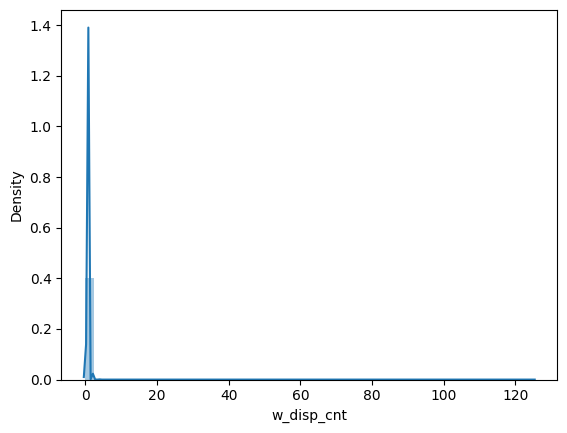

In [38]:
#import matplotlib.pyplot as plt
plt.figure()
sns.distplot(train_data['w_disp_cnt'])
plt.show()

In [39]:
train_data['w_disp_cnt'].value_counts()

,count
w_disp_cnt,
1.0,38218
0.0,15939
2.0,765
3.0,37
4.0,16
32.0,3
125.0,3
5.0,3
6.0,3


/tmp/ipykernel_1091/4268541907.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data['w_disp_cnt']<10)


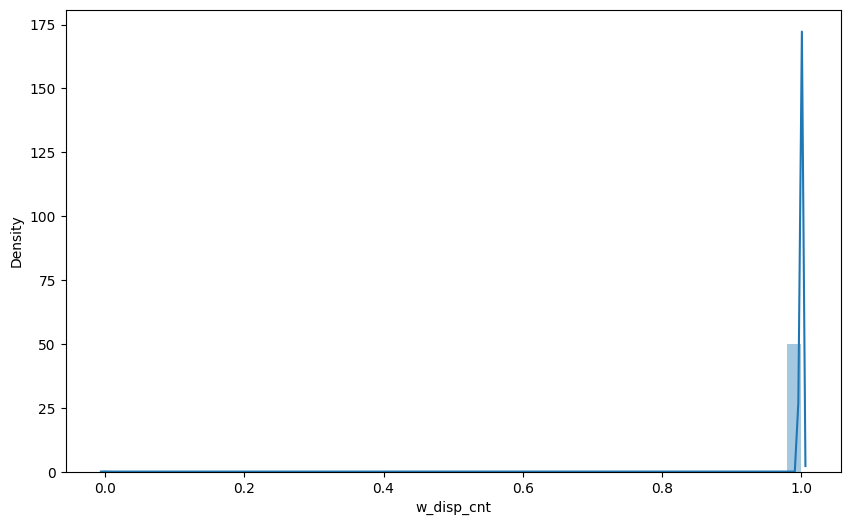

In [40]:
plt.figure(figsize=(10,6))
sns.distplot(train_data['w_disp_cnt']<10)
plt.show()

/tmp/ipykernel_1091/134682830.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=train_data[train_data['w_disp_cnt']<10]['w_disp_cnt'])


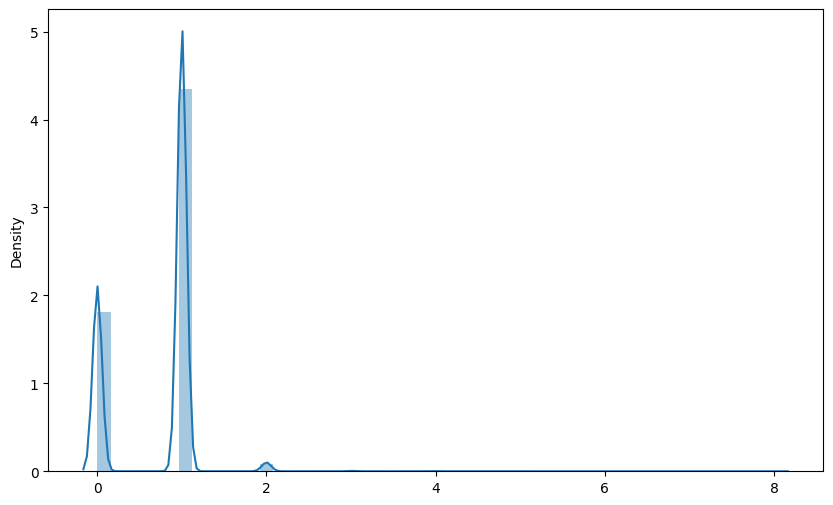

In [41]:
plt.figure(figsize=(10, 6))
sns.distplot(x=train_data[train_data['w_disp_cnt']<10]['w_disp_cnt'])
plt.show()

In [42]:
train_data['w_disp_cnt'].fillna(train_data['w_disp_cnt'].median(), inplace=True)
train_data.isnull().sum().sum(), test_data.isnull().sum().sum()

/tmp/ipykernel_1091/3568569247.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['w_disp_cnt'].fillna(train_data['w_disp_cnt'].median(), inplace=True)


(np.int64(0), np.int64(0))

In [43]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 46 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    55000 non-null  object 
 1   status                55000 non-null  object 
 2   new_date              55000 non-null  int64  
 3   bidet_cnt             55000 non-null  int64  
 4   w_disp_cnt            55000 non-null  float64
 5   cust_cd               55000 non-null  int64  
 6   sex_cd                55000 non-null  object 
 7   w_disp_yn             55000 non-null  object 
 8   bidet_yn              55000 non-null  object 
 9   comb_prod_yn          55000 non-null  object 
 10  bidet_comb_yn         55000 non-null  object 
 11  w_disp_comb_yn        55000 non-null  object 
 12  bidet_trmn_eperd_cd   55000 non-null  object 
 13  w_disp_trmn_eperd_cd  55000 non-null  object 
 14  w_disp_trmn_why_cd    55000 non-null  object 
 15  bidet_trmn_why_cd  

In [44]:
train_data['new_date']


,new_date
0,20170421
1,20131203
2,20170731
3,20090930
4,20151121
...,...
54995,20050916
54996,20130117
54997,20190709
54998,20190812


In [45]:
train_data[['cust_cd', 'new_date']].head(10)

,cust_cd,new_date
0,10001,20170421
1,10001,20131203
2,10001,20170731
3,10001,20090930
4,10001,20151121
5,10001,20120711
6,10001,20170329
7,10001,20181109
8,10001,20140116
9,10001,20180810


In [46]:
train_data['new_date'] = train_data['new_date'].astype('str').astype('datetime64[ns]')
test_data['new_date'] = train_data['new_date'].astype('str').astype('datetime64[ns]')

In [47]:
print(f" train_data : {train_data['new_date'].head(10)}")
print(f" test_date : {test_data['new_date'].tail(10)}")


 train_data : 0   2017-04-21
1   2013-12-03
2   2017-07-31
3   2009-09-30
4   2015-11-21
5   2012-07-11
6   2017-03-29
7   2018-11-09
8   2014-01-16
9   2018-08-10
Name: new_date, dtype: datetime64[ns]
 test_date : 4990   2015-09-23
4991   2019-11-14
4992   2012-09-10
4993   2013-08-06
4994   2020-07-10
4995   2017-12-18
4996   2016-11-12
4997   2016-12-02
4998   2016-01-29
4999   2014-06-10
Name: new_date, dtype: datetime64[ns]


In [48]:
train_data['new_date'].dtype

dtype('<M8[ns]')

In [49]:
test_data['new_date'].dtype

dtype('<M8[ns]')

In [50]:
train_data['cust_cd'] = train_data['cust_cd'].astype('object')
test_data['cust_cd'] = test_data['cust_cd'].astype('object')

In [51]:
print(f" data type ? train_data['cust_cd'] : {train_data['cust_cd'].dtype}, test_data['cust_cd'] : {test_data['cust_cd'].dtype}")

 data type ? train_data['cust_cd'] : object, test_data['cust_cd'] : object


In [52]:
print(f" max values? train_data['new_date'] : {train_data['new_date'].max()}, test_data['new_date'] : {test_data['new_date'].max()}")

 max values? train_data['new_date'] : 2020-08-31 00:00:00, test_data['new_date'] : 2020-08-28 00:00:00


In [53]:
print(f" max values? train_data['new_date'] : {train_data['new_date'].max()}",
      f" test_data['new_date'] : {test_data['new_date'].max()}")

 max values? train_data['new_date'] : 2020-08-31 00:00:00  test_data['new_date'] : 2020-08-28 00:00:00


In [54]:
(datetime(2020,8,31,0,0) - train_data['new_date']).head(10)

,new_date
0,1228 days
1,2463 days
2,1127 days
3,3988 days
4,1745 days
5,2973 days
6,1251 days
7,661 days
8,2419 days
9,752 days


In [55]:
train_data['join_period'] = (datetime(2020,8,31,0,0) - train_data['new_date']).dt.days
test_data['join_period'] = (datetime(2020,8,3,0,0) - test_data['new_date']).dt.days

In [56]:
train_data['join_period'].head(), test_data['join_period'].head()

(0    1228
 1    2463
 2    1127
 3    3988
 4    1745
 Name: join_period, dtype: int64,
 0    1200
 1    2435
 2    1099
 3    3960
 4    1717
 Name: join_period, dtype: int64)

In [57]:
teperd_cols=['w_disp_trmn_eperd_cd', 'bidet_trmn_eperd_cd']

In [58]:
train_data[teperd_cols]

,w_disp_trmn_eperd_cd,bidet_trmn_eperd_cd
0,_,_
1,_,_
2,_,_
3,_,_
4,_,_
...,...,...
54995,_,_
54996,_,R37
54997,_,_
54998,_,_


In [59]:
#'w_disp_trmn_eperd_cd', 'bidet_trmn_eperd_cd'

train_data['w_disp_trmn_eperd_cd'].value_counts()

,count
w_disp_trmn_eperd_cd,
_,51578
R37,1161
0,462
R01,120
R02,86
R06,85
R05,82
R04,78
R03,69


In [60]:
def Rctoint(Rcd) :
  if Rcd == '_' :
    return 38

  elif Rcd =='0' :
    return 0

  else :
    return int(Rcd[1:3])

#teperd_cols=['w_disp_trmn_eperd_cd', 'bidet_trmn_eperd_cd']

for column in teperd_cols :
  new_column = column.replace('_trmn_eperd_cd', '_teperd')
  train_data[new_column] = train_data[column].apply(lambda x : Rctoint(x))
  test_data[new_column] = test_data[column].apply(lambda x : Rctoint(x))

train_data.iloc[:,-2:].head(), test_data.iloc[:, -2:].head()



(   w_disp_teperd  bidet_teperd
 0             38            38
 1             38            38
 2             38            38
 3             38            38
 4             38            38,
    w_disp_teperd  bidet_teperd
 0             38            38
 1             38            38
 2             38            38
 3             38            38
 4             38            38)

In [61]:
train_data.columns

Index(['id', 'status', 'new_date', 'bidet_cnt', 'w_disp_cnt', 'cust_cd',
       'sex_cd', 'w_disp_yn', 'bidet_yn', 'comb_prod_yn', 'bidet_comb_yn',
       'w_disp_comb_yn', 'bidet_trmn_eperd_cd', 'w_disp_trmn_eperd_cd',
       'w_disp_trmn_why_cd', 'bidet_trmn_why_cd', 'npay_yn', '3m_avg_bill_amt',
       '3m_bidet_avg_amt', '3m_w_disp_avg_amt', 'w_disp_engt_rperd_cd',
       'bidet_engt_rperd_cd', 'voc_cntAS', 'voc_cnt가입', 'voc_cnt개통',
       'voc_cnt변경/조회', 'voc_cnt업무협조', 'voc_cnt이용', 'voc_cnt정보보호/언론보도',
       'voc_cnt채널', 'voc_cnt청구 수/미납', 'voc_cnt품질', 'voc_cnt해지', 'voc_cnt혜택',
       'day_cntAS', 'day_cnt가입', 'day_cnt개통', 'day_cnt변경/조회', 'day_cnt업무협조',
       'day_cnt이용', 'day_cnt정보보호/언론보도', 'day_cnt채널', 'day_cnt청구 수/미납',
       'day_cnt품질', 'day_cnt해지', 'day_cnt혜택', 'join_period', 'w_disp_teperd',
       'bidet_teperd'],
      dtype='object')

In [62]:
erperd_cols = ['w_disp_engt_rperd_cd', 'bidet_engt_rperd_cd']

train_data[erperd_cols].head(), test_data[erperd_cols].head()

(  w_disp_engt_rperd_cd bidet_engt_rperd_cd
 0                  R09                 R12
 1                    _                 R06
 2                    0                   _
 3                  P36                 R11
 4                  R27                 R22,
   w_disp_engt_rperd_cd bidet_engt_rperd_cd
 0                  R13                 R10
 1                    _                   0
 2                    _                 R06
 3                  R34                 R14
 4                  R36                 R23)

In [63]:
train_data['bidet_engt_rperd_cd'].value_counts()

,count
bidet_engt_rperd_cd,
_,10996
R12,3864
R07,2108
R06,1940
R11,1888
...,...
P33,29
P35,20
P36,20


In [64]:
train_data['bidet_engt_rperd_cd'].value_counts().index, train_data['w_disp_engt_rperd_cd'].value_counts().index

(Index(['_', 'R12', 'R07', 'R06', 'R11', 'R10', 'R09', 'R13', 'R24', 'R08',
        'R23', 'R14', 'R22', 'R05', 'R15', 'R04', 'R21', 'R02', 'R01', 'R30',
        'R20', 'R18', 'R16', 'R03', 'R19', 'R29', 'R17', '0', 'R28', 'R25',
        'P37', 'R26', 'R27', 'P01', '|', 'P02', 'P04', 'P06', 'P03', 'P07',
        'P05', 'P08', 'P09', 'P11', 'P12', 'P10', 'P15', 'P14', 'P13', 'P16',
        'P18', 'P19', 'P22', 'P20', 'P21', 'P24', 'P17', 'P23', 'P25', 'P26',
        'P28', 'P31', 'P32', 'P27', 'P30', 'P29', 'P33', 'P35', 'P36', 'P34',
        'R34'],
       dtype='object', name='bidet_engt_rperd_cd'),
 Index(['_', 'P37', 'R01', 'R36', '0', 'R35', 'R12', 'P01', 'R10', 'R11', 'R13',
        'R08', 'R27', 'R09', 'R20', 'R24', 'R34', 'R22', 'R18', 'R33', 'R21',
        'P02', 'R15', 'R25', 'R16', 'R28', 'R17', 'R14', 'R29', 'R32', 'R26',
        'P04', 'R02', 'R23', 'R06', 'R19', 'R30', 'R04', 'P03', 'R31', 'R07',
        'R03', 'R05', 'P05', 'P12', 'P06', 'P14', 'P07', 'P08', 'P09', 'P13',

In [65]:
def RPcdtoint(Rpcd) :

  if Rpcd == '_' :
     return int(38)

  elif Rpcd =='0' :
     return int(0)

  elif Rpcd =='|' :
     return int(38)

  elif Rpcd[0] == 'p' :
     return int(Rpcd[1:3])

  else :
     return -int(Rpcd[1:3])

In [66]:
#erperd_cols = ['w_disp_engt_rperd_cd', 'bidet_engt_rperd_cd']

for column in erperd_cols :

  new_column = column.replace('_engt_rperd_cd', '_erperd')
  #train_data[new_column] = ' '
  #test_data[new_column] = ' '

  train_data[new_column] = train_data[column].map(lambda x : RPcdtoint(x))
  test_data[new_column] = test_data[column].map(lambda x : RPcdtoint(x))


In [67]:
train_data.columns, test_data.columns

(Index(['id', 'status', 'new_date', 'bidet_cnt', 'w_disp_cnt', 'cust_cd',
        'sex_cd', 'w_disp_yn', 'bidet_yn', 'comb_prod_yn', 'bidet_comb_yn',
        'w_disp_comb_yn', 'bidet_trmn_eperd_cd', 'w_disp_trmn_eperd_cd',
        'w_disp_trmn_why_cd', 'bidet_trmn_why_cd', 'npay_yn', '3m_avg_bill_amt',
        '3m_bidet_avg_amt', '3m_w_disp_avg_amt', 'w_disp_engt_rperd_cd',
        'bidet_engt_rperd_cd', 'voc_cntAS', 'voc_cnt가입', 'voc_cnt개통',
        'voc_cnt변경/조회', 'voc_cnt업무협조', 'voc_cnt이용', 'voc_cnt정보보호/언론보도',
        'voc_cnt채널', 'voc_cnt청구 수/미납', 'voc_cnt품질', 'voc_cnt해지', 'voc_cnt혜택',
        'day_cntAS', 'day_cnt가입', 'day_cnt개통', 'day_cnt변경/조회', 'day_cnt업무협조',
        'day_cnt이용', 'day_cnt정보보호/언론보도', 'day_cnt채널', 'day_cnt청구 수/미납',
        'day_cnt품질', 'day_cnt해지', 'day_cnt혜택', 'join_period', 'w_disp_teperd',
        'bidet_teperd', 'w_disp_erperd', 'bidet_erperd'],
       dtype='object'),
 Index(['id', 'status', 'new_date', 'bidet_cnt', 'w_disp_cnt', 'cust_cd',
        'sex_cd', 

In [68]:
train_data.iloc[:,-2:].head(), test_data.iloc[:,-2:].head()

(   w_disp_erperd  bidet_erperd
 0             -9           -12
 1             38            -6
 2              0            38
 3            -36           -11
 4            -27           -22,
    w_disp_erperd  bidet_erperd
 0            -13           -10
 1             38             0
 2             38            -6
 3            -34           -14
 4            -36           -23)

In [69]:
del_cols=[]

In [70]:
del_cols.append('id')

In [71]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 51 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    55000 non-null  object        
 1   status                55000 non-null  object        
 2   new_date              55000 non-null  datetime64[ns]
 3   bidet_cnt             55000 non-null  int64         
 4   w_disp_cnt            55000 non-null  float64       
 5   cust_cd               55000 non-null  object        
 6   sex_cd                55000 non-null  object        
 7   w_disp_yn             55000 non-null  object        
 8   bidet_yn              55000 non-null  object        
 9   comb_prod_yn          55000 non-null  object        
 10  bidet_comb_yn         55000 non-null  object        
 11  w_disp_comb_yn        55000 non-null  object        
 12  bidet_trmn_eperd_cd   55000 non-null  object        
 13  w_disp_trmn_eper

In [72]:
number=['int64', 'float64']

num_cols = train_data.select_dtypes(number).columns

In [73]:
num_cols.value_counts().sum()

np.int64(34)

In [74]:
obj_cols = train_data.select_dtypes('object').columns

In [75]:
obj_cols.value_counts().sum()

np.int64(16)

In [76]:
round(train_data[num_cols].describe(), 3)

,bidet_cnt,w_disp_cnt,3m_avg_bill_amt,3m_bidet_avg_amt,3m_w_disp_avg_amt,voc_cntAS,voc_cnt가입,voc_cnt개통,voc_cnt변경/조회,voc_cnt업무협조,...,day_cnt채널,day_cnt청구 수/미납,day_cnt품질,day_cnt해지,day_cnt혜택,join_period,w_disp_teperd,bidet_teperd,w_disp_erperd,bidet_erperd
count,55000.000,55000.000,5.500000e+04,55000.000,5.500000e+04,55000.000,55000.000,55000.000,55000.000,55000.000,...,55000.000,55000.000,55000.000,55000.000,55000.000,55000.000,55000.000,55000.000,55000.000,55000.000
mean,2.597,0.737,2.915999e+05,34411.052,4.162946e+04,0.044,0.130,0.019,0.215,0.332,...,0.075,0.220,0.110,0.273,0.036,1858.126,36.910,36.868,4.682,-2.885
std,66.479,1.137,8.496803e+05,38330.909,3.965128e+05,0.256,0.366,0.167,0.553,0.886,...,0.316,0.465,0.352,0.519,0.205,1616.054,5.628,5.709,29.975,22.217
min,0.000,0.000,-1.136300e+04,0.000,0.000000e+00,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-37.000,-37.000
25%,1.000,0.000,1.102485e+05,11310.500,0.000000e+00,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,748.000,38.000,38.000,-23.000,-17.000
50%,1.000,1.000,1.994620e+05,31075.500,3.266000e+04,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,1357.000,38.000,38.000,-2.000,-10.000
75%,2.000,1.000,3.363402e+05,48041.250,4.791800e+04,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,2517.000,38.000,38.000,38.000,-2.000
max,5077.000,125.000,1.806220e+08,3092769.000,6.078027e+07,7.000,6.000,5.000,59.000,102.000,...,9.000,7.000,7.000,6.000,6.000,8396.000,38.000,38.000,38.000,38.000


In [77]:
for column in num_cols :
  if ((train_data[column] == 0).sum() >= (train_data.value_counts().sum())*0.9 ):

    print(f" train_data[{column}] : { (train_data[column] == 0).sum() / train_data[column].value_counts().sum() }")

    del_cols.append(column)


 train_data[voc_cntAS] : 0.9651272727272727
 train_data[voc_cnt개통] : 0.9838181818181818
 train_data[voc_cnt정보보호/언론보도] : 0.9937090909090909
 train_data[voc_cnt채널] : 0.9343090909090909
 train_data[voc_cnt품질] : 0.9000363636363636
 train_data[voc_cnt혜택] : 0.9671818181818181
 train_data[day_cntAS] : 0.9651272727272727
 train_data[day_cnt개통] : 0.9838181818181818
 train_data[day_cnt정보보호/언론보도] : 0.9937090909090909
 train_data[day_cnt채널] : 0.9343090909090909
 train_data[day_cnt품질] : 0.9000363636363636
 train_data[day_cnt혜택] : 0.9671818181818181


In [78]:
del_cols

['id',
 'voc_cntAS',
 'voc_cnt개통',
 'voc_cnt정보보호/언론보도',
 'voc_cnt채널',
 'voc_cnt품질',
 'voc_cnt혜택',
 'day_cntAS',
 'day_cnt개통',
 'day_cnt정보보호/언론보도',
 'day_cnt채널',
 'day_cnt품질',
 'day_cnt혜택']

In [79]:
for column in obj_cols :

  if ( (train_data[column].value_counts().iloc[0]/train_data[column].value_counts().sum()) > 0.9)  :

    print(f" train_data[{column}] : {(train_data[column].value_counts().iloc[0])/(train_data[column].value_counts().sum())}")

    del_cols.append(column)

 train_data[cust_cd] : 0.9760181818181818
 train_data[bidet_trmn_eperd_cd] : 0.9267454545454545
 train_data[w_disp_trmn_eperd_cd] : 0.9377818181818182
 train_data[w_disp_trmn_why_cd] : 0.9420363636363637
 train_data[bidet_trmn_why_cd] : 0.9294363636363636


In [80]:
del_cols

['id',
 'voc_cntAS',
 'voc_cnt개통',
 'voc_cnt정보보호/언론보도',
 'voc_cnt채널',
 'voc_cnt품질',
 'voc_cnt혜택',
 'day_cntAS',
 'day_cnt개통',
 'day_cnt정보보호/언론보도',
 'day_cnt채널',
 'day_cnt품질',
 'day_cnt혜택',
 'cust_cd',
 'bidet_trmn_eperd_cd',
 'w_disp_trmn_eperd_cd',
 'w_disp_trmn_why_cd',
 'bidet_trmn_why_cd']

In [81]:
del_cols = del_cols+['new_date', 'w_disp_engt_rperd_cd', 'bidet_engt_rperd_cd']
del_cols

['id',
 'voc_cntAS',
 'voc_cnt개통',
 'voc_cnt정보보호/언론보도',
 'voc_cnt채널',
 'voc_cnt품질',
 'voc_cnt혜택',
 'day_cntAS',
 'day_cnt개통',
 'day_cnt정보보호/언론보도',
 'day_cnt채널',
 'day_cnt품질',
 'day_cnt혜택',
 'cust_cd',
 'bidet_trmn_eperd_cd',
 'w_disp_trmn_eperd_cd',
 'w_disp_trmn_why_cd',
 'bidet_trmn_why_cd',
 'new_date',
 'w_disp_engt_rperd_cd',
 'bidet_engt_rperd_cd']

In [82]:
train_data.drop(del_cols, axis=1, inplace=True)
test_data.drop(del_cols, axis=1, inplace=True)
print(f" train_data information : {train_data.info()}")
print(f" test_data information : {test_data.info()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   status             55000 non-null  object 
 1   bidet_cnt          55000 non-null  int64  
 2   w_disp_cnt         55000 non-null  float64
 3   sex_cd             55000 non-null  object 
 4   w_disp_yn          55000 non-null  object 
 5   bidet_yn           55000 non-null  object 
 6   comb_prod_yn       55000 non-null  object 
 7   bidet_comb_yn      55000 non-null  object 
 8   w_disp_comb_yn     55000 non-null  object 
 9   npay_yn            55000 non-null  object 
 10  3m_avg_bill_amt    55000 non-null  float64
 11  3m_bidet_avg_amt   55000 non-null  int64  
 12  3m_w_disp_avg_amt  55000 non-null  int64  
 13  voc_cnt가입          55000 non-null  int64  
 14  voc_cnt변경/조회       55000 non-null  int64  
 15  voc_cnt업무협조        55000 non-null  int64  
 16  voc_cnt이용          550

In [83]:
train_data['status'].value_counts()

,count
status,
Y,31806
N,23194


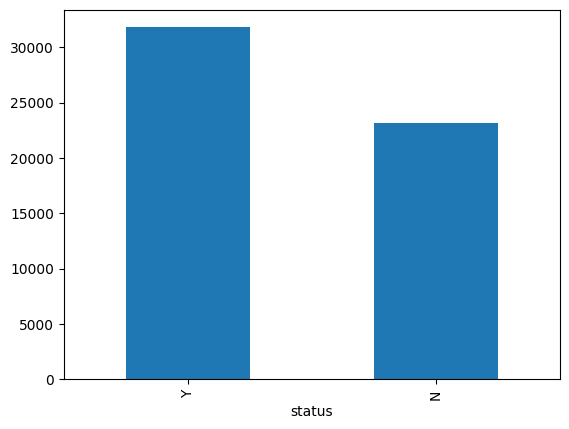

In [84]:
plt.figure()
train_data['status'].value_counts().plot(kind='bar')
plt.show()

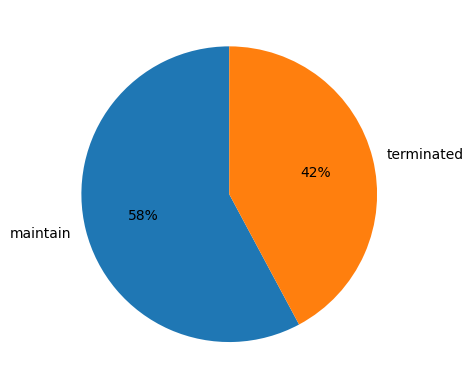

In [85]:
data = train_data['status'].value_counts()
labels = ['maintain', 'terminated']
#, shadow=True, explode=(0,0.1),startangle=90
plt.pie(data, labels=labels, autopct ='%.0f%%', startangle=90)
# plt.title(["유지", "해지"])
plt.show()

In [86]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   status             55000 non-null  object 
 1   bidet_cnt          55000 non-null  int64  
 2   w_disp_cnt         55000 non-null  float64
 3   sex_cd             55000 non-null  object 
 4   w_disp_yn          55000 non-null  object 
 5   bidet_yn           55000 non-null  object 
 6   comb_prod_yn       55000 non-null  object 
 7   bidet_comb_yn      55000 non-null  object 
 8   w_disp_comb_yn     55000 non-null  object 
 9   npay_yn            55000 non-null  object 
 10  3m_avg_bill_amt    55000 non-null  float64
 11  3m_bidet_avg_amt   55000 non-null  int64  
 12  3m_w_disp_avg_amt  55000 non-null  int64  
 13  voc_cnt가입          55000 non-null  int64  
 14  voc_cnt변경/조회       55000 non-null  int64  
 15  voc_cnt업무협조        55000 non-null  int64  
 16  voc_cnt이용          550

In [87]:
numbers = ['int64', 'float64']
num_cols = train_data.select_dtypes(numbers).columns
num_cols

Index(['bidet_cnt', 'w_disp_cnt', '3m_avg_bill_amt', '3m_bidet_avg_amt',
       '3m_w_disp_avg_amt', 'voc_cnt가입', 'voc_cnt변경/조회', 'voc_cnt업무협조',
       'voc_cnt이용', 'voc_cnt청구 수/미납', 'voc_cnt해지', 'day_cnt가입', 'day_cnt변경/조회',
       'day_cnt업무협조', 'day_cnt이용', 'day_cnt청구 수/미납', 'day_cnt해지',
       'join_period', 'w_disp_teperd', 'bidet_teperd', 'w_disp_erperd',
       'bidet_erperd'],
      dtype='object')

number of target columns: 22


100%|██████████| 22/22 [00:00<00:00, 98.33it/s] 
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sa

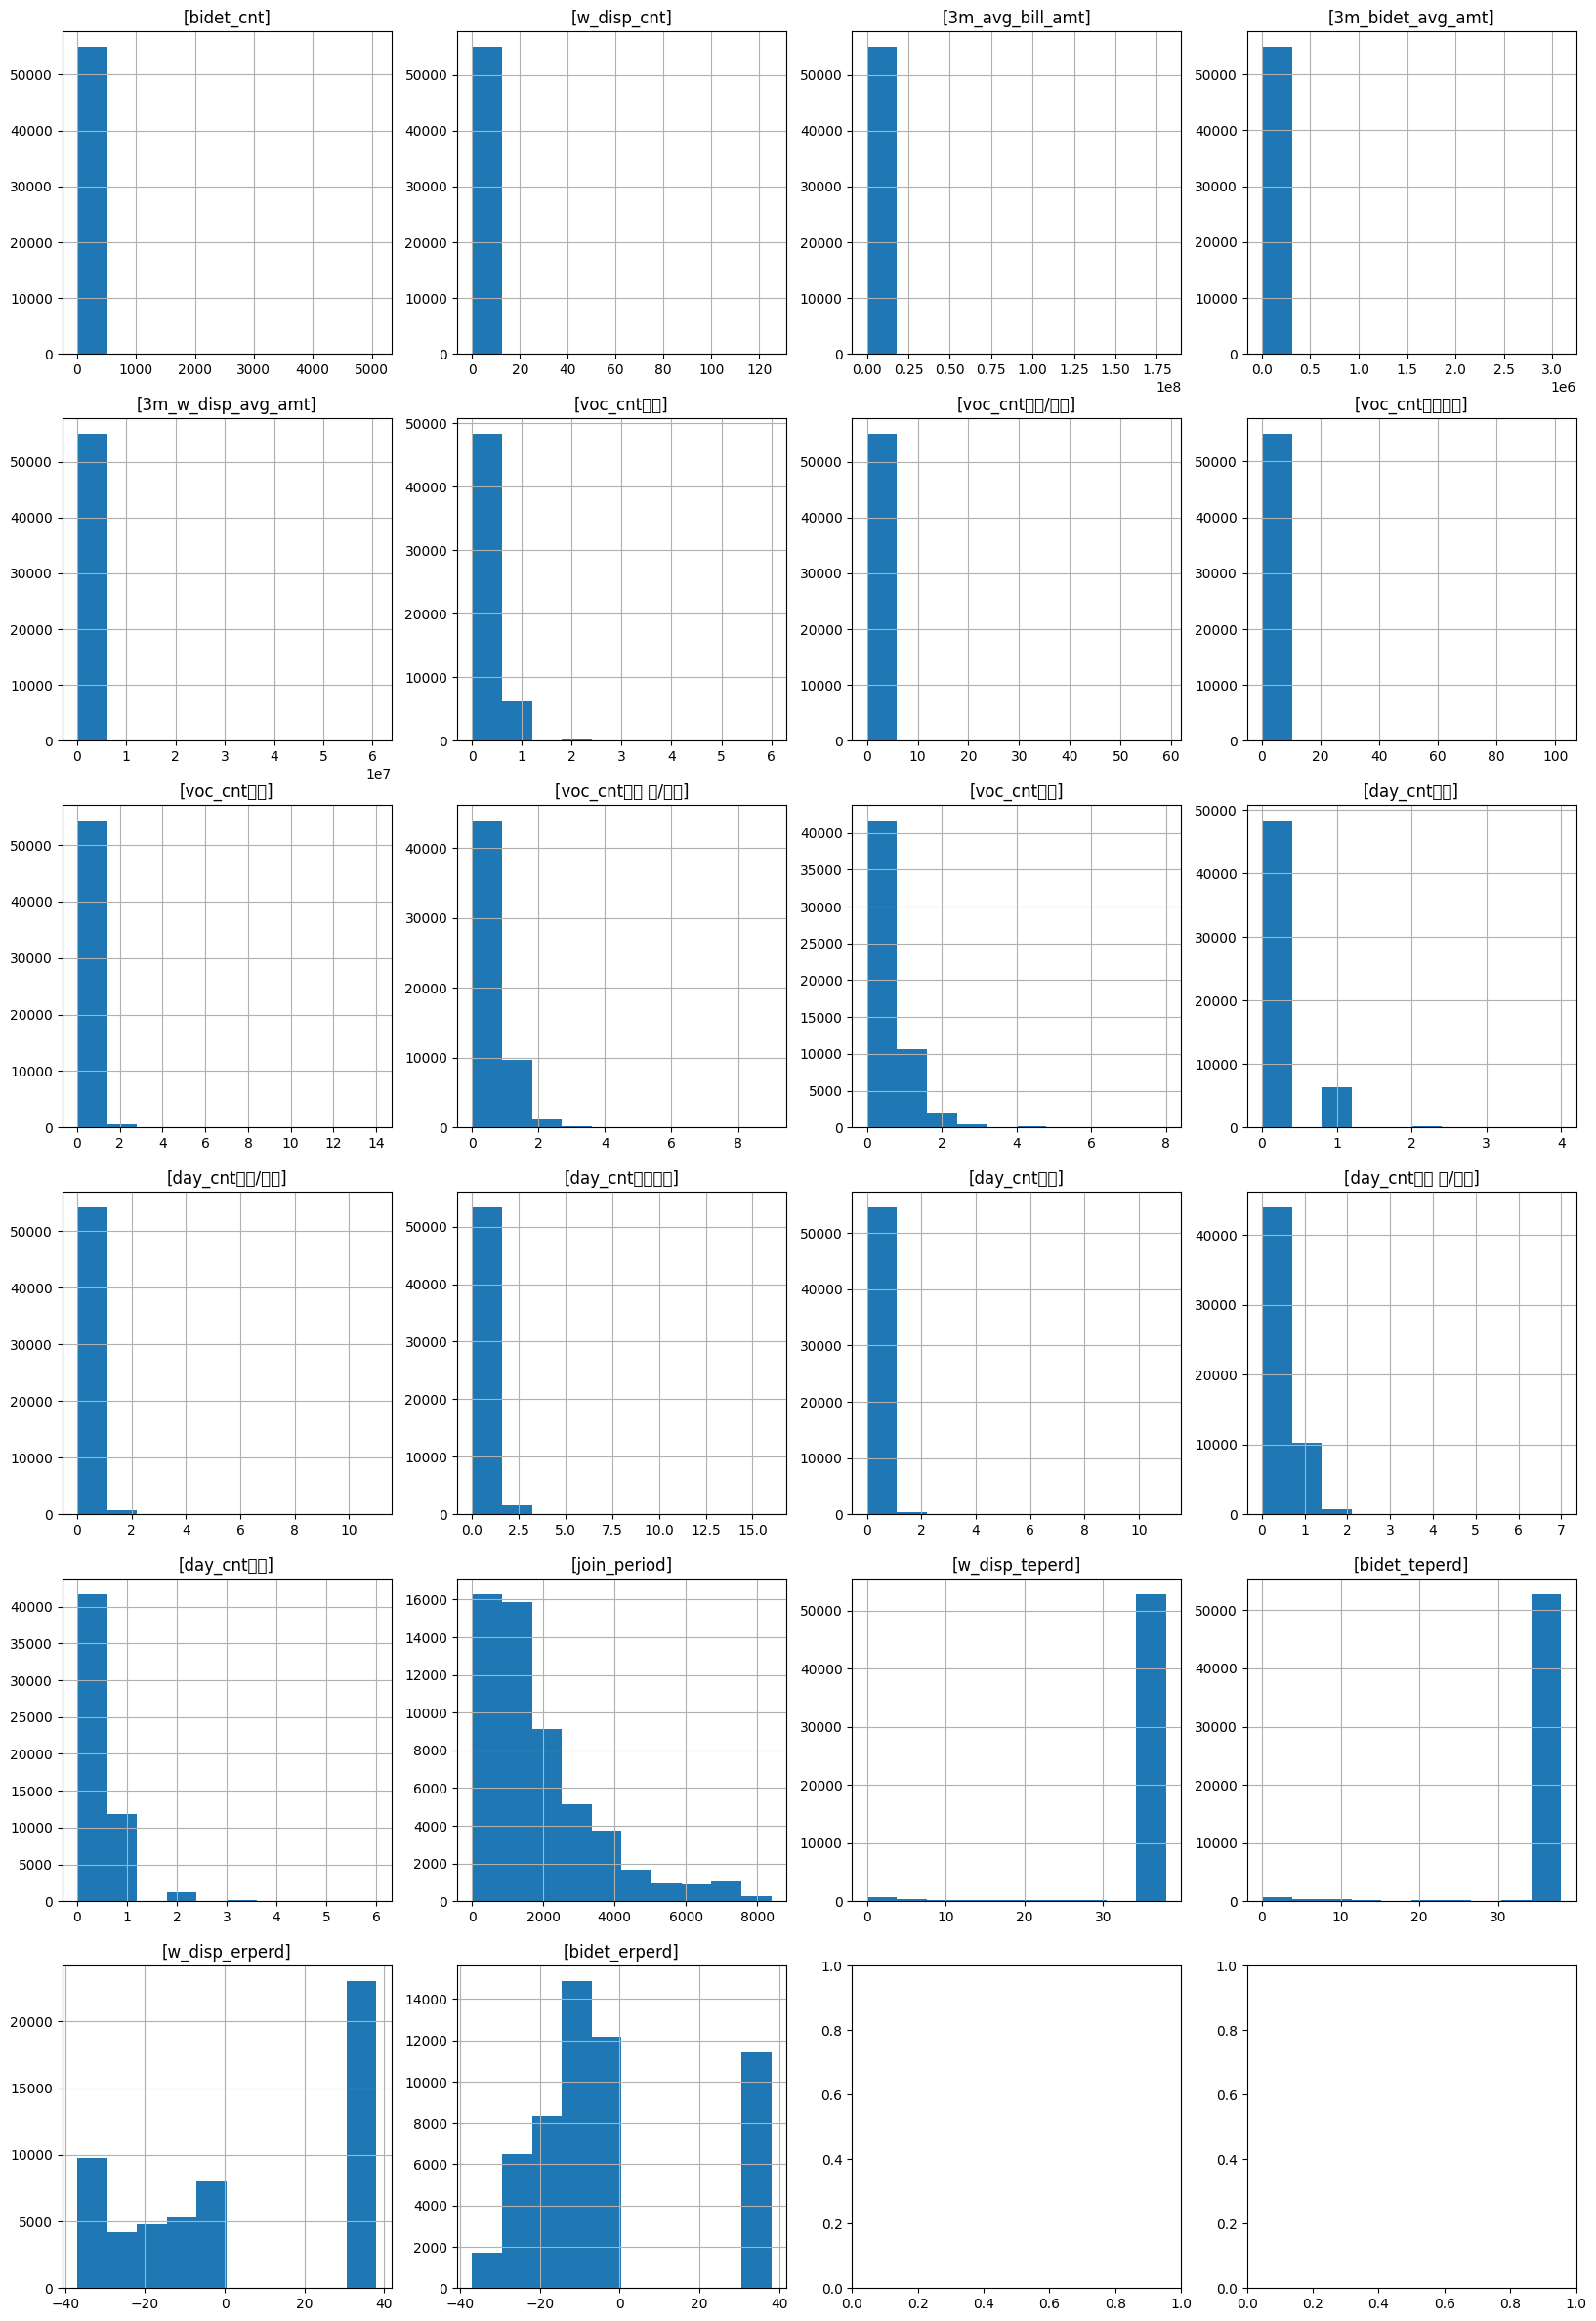

In [88]:
def make_histplot(df, num_cols, label):
  col_cnt = 4
  graph_size = 5
  num = len(num_cols)
  print("number of target columns:", num)

  plt.rcParams['figure.figsize'] = (col_cnt*graph_size,math.ceil(num/col_cnt)*graph_size)

  fig, ax = plt.subplots(ncols=col_cnt, nrows=math.ceil(num/col_cnt))
  i = 0

  for column in tqdm(num_cols):
    df[column].hist(ax=ax[int(i/col_cnt)][i%col_cnt])
    ax[int(i/col_cnt)][i%col_cnt].set_title('['+column+']')

    i = i+1
  plt.show()
  plt.rcParams['figure.figsize']=(7,7)

make_histplot(train_data, num_cols, 'status')

In [89]:
train_data.describe()

,bidet_cnt,w_disp_cnt,3m_avg_bill_amt,3m_bidet_avg_amt,3m_w_disp_avg_amt,voc_cnt가입,voc_cnt변경/조회,voc_cnt업무협조,voc_cnt이용,voc_cnt청구 수/미납,...,day_cnt변경/조회,day_cnt업무협조,day_cnt이용,day_cnt청구 수/미납,day_cnt해지,join_period,w_disp_teperd,bidet_teperd,w_disp_erperd,bidet_erperd
count,55000.000000,55000.000000,5.500000e+04,5.500000e+04,5.500000e+04,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,...,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000
mean,2.596782,0.737255,2.915999e+05,3.441105e+04,4.162946e+04,0.129927,0.214673,0.332455,0.124055,0.232273,...,0.201436,0.284218,0.117691,0.219764,0.272909,1858.126418,36.910036,36.868073,4.682109,-2.884727
std,66.479010,1.137088,8.496803e+05,3.833091e+04,3.965128e+05,0.366102,0.552657,0.885980,0.398879,0.510258,...,0.447934,0.580211,0.362700,0.464854,0.518703,1616.054444,5.627786,5.708939,29.974697,22.216923
min,0.000000,0.000000,-1.136300e+04,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-37.000000,-37.000000
25%,1.000000,0.000000,1.102485e+05,1.131050e+04,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,748.000000,38.000000,38.000000,-23.000000,-17.000000
50%,1.000000,1.000000,1.994620e+05,3.107550e+04,3.266000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1357.000000,38.000000,38.000000,-2.000000,-10.000000
75%,2.000000,1.000000,3.363403e+05,4.804125e+04,4.791800e+04,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2517.000000,38.000000,38.000000,38.000000,-2.000000
max,5077.000000,125.000000,1.806220e+08,3.092769e+06,6.078027e+07,6.000000,59.000000,102.000000,14.000000,9.000000,...,11.000000,16.000000,11.000000,7.000000,6.000000,8396.000000,38.000000,38.000000,38.000000,38.000000


In [90]:


train_data.max()

,0
status,Y
bidet_cnt,5077
w_disp_cnt,125.0
sex_cd,_
w_disp_yn,Y
bidet_yn,Y
comb_prod_yn,Y
bidet_comb_yn,Y
w_disp_comb_yn,Y
npay_yn,Y


In [91]:
outlier_cols = train_data.describe().loc['max'][train_data.describe().loc['max']>=20].index.tolist()

In [92]:

outlier_cols

['bidet_cnt',
 'w_disp_cnt',
 '3m_avg_bill_amt',
 '3m_bidet_avg_amt',
 '3m_w_disp_avg_amt',
 'voc_cnt변경/조회',
 'voc_cnt업무협조',
 'join_period',
 'w_disp_teperd',
 'bidet_teperd',
 'w_disp_erperd',
 'bidet_erperd']

In [93]:
def outlier_iqr(df, columns) :

 for col in columns :

  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3-q1

  upper = q3 + (iqr*1.5)
  lower = q1 - (iqr*1.5)

  df.loc[df[col]>upper, col] = upper
  df.loc[df[col]<lower, col] = lower

 return df

In [94]:
train_data = outlier_iqr(train_data, outlier_cols)

/tmp/ipykernel_1091/2046081993.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col]>upper, col] = upper
/tmp/ipykernel_1091/2046081993.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '103137.375' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col]>upper, col] = upper
/tmp/ipykernel_1091/2046081993.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5170.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col]>upper, col] = upper
/tmp/ipykernel_1091/2046081993.py:12: FutureWarning: Setting an item of incompatible dtype is deprecat

In [95]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   status             55000 non-null  object 
 1   bidet_cnt          55000 non-null  float64
 2   w_disp_cnt         55000 non-null  float64
 3   sex_cd             55000 non-null  object 
 4   w_disp_yn          55000 non-null  object 
 5   bidet_yn           55000 non-null  object 
 6   comb_prod_yn       55000 non-null  object 
 7   bidet_comb_yn      55000 non-null  object 
 8   w_disp_comb_yn     55000 non-null  object 
 9   npay_yn            55000 non-null  object 
 10  3m_avg_bill_amt    55000 non-null  float64
 11  3m_bidet_avg_amt   55000 non-null  float64
 12  3m_w_disp_avg_amt  55000 non-null  int64  
 13  voc_cnt가입          55000 non-null  int64  
 14  voc_cnt변경/조회       55000 non-null  int64  
 15  voc_cnt업무협조        55000 non-null  int64  
 16  voc_cnt이용          550

In [96]:
num_cols

Index(['bidet_cnt', 'w_disp_cnt', '3m_avg_bill_amt', '3m_bidet_avg_amt',
       '3m_w_disp_avg_amt', 'voc_cnt가입', 'voc_cnt변경/조회', 'voc_cnt업무협조',
       'voc_cnt이용', 'voc_cnt청구 수/미납', 'voc_cnt해지', 'day_cnt가입', 'day_cnt변경/조회',
       'day_cnt업무협조', 'day_cnt이용', 'day_cnt청구 수/미납', 'day_cnt해지',
       'join_period', 'w_disp_teperd', 'bidet_teperd', 'w_disp_erperd',
       'bidet_erperd'],
      dtype='object')

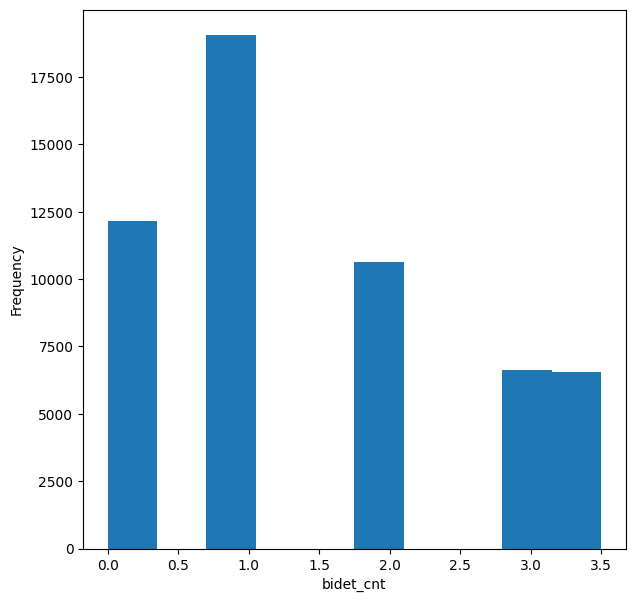

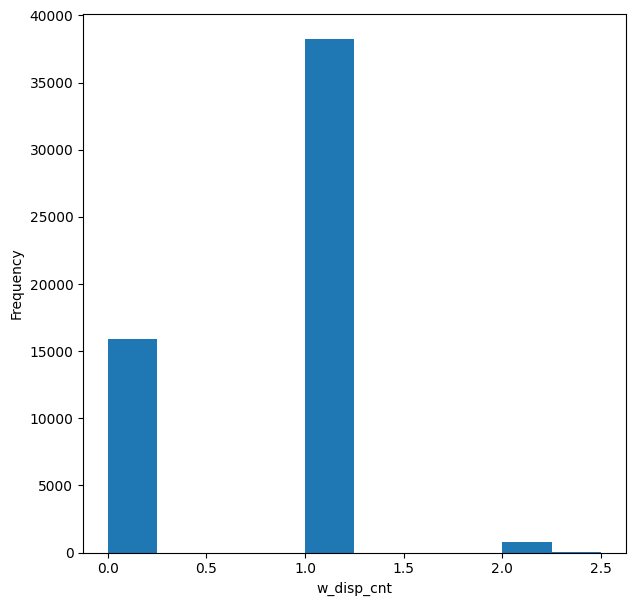

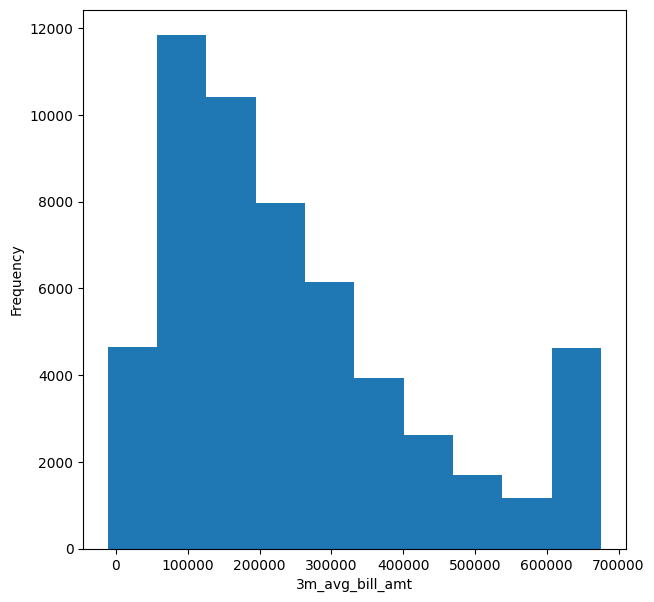

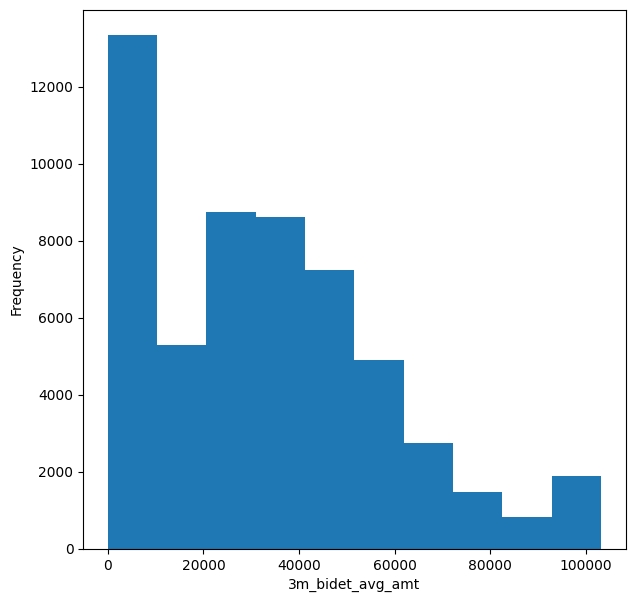

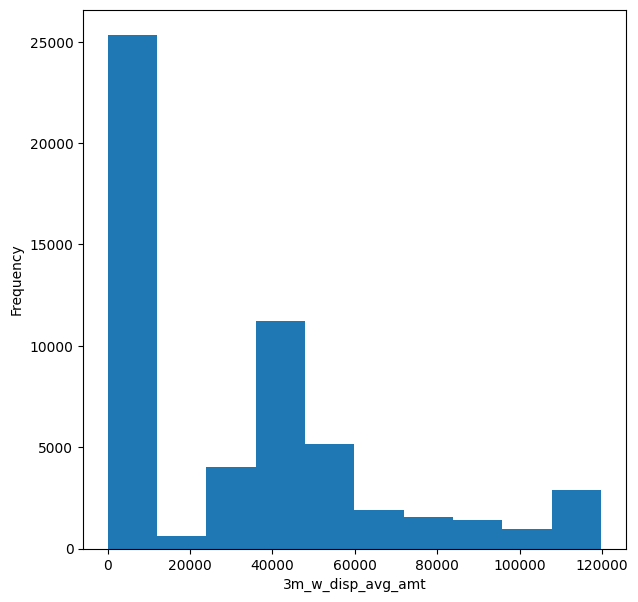

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


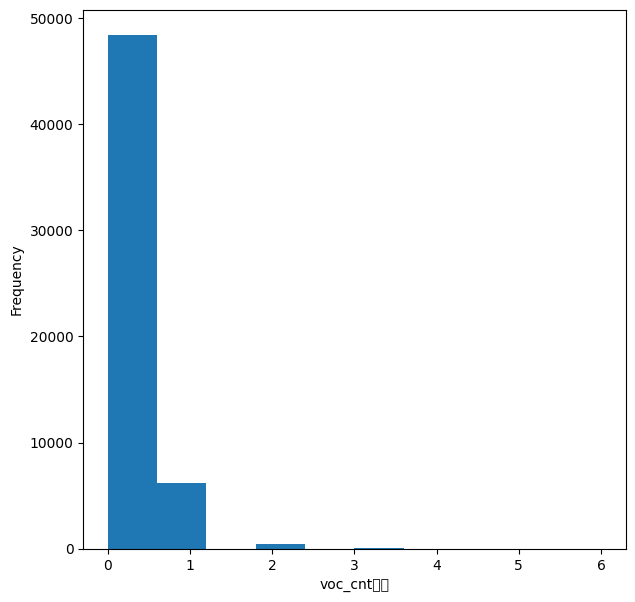

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


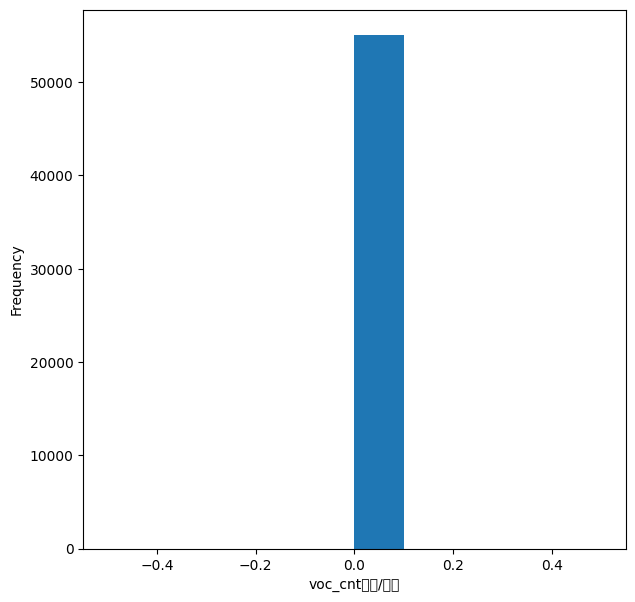

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


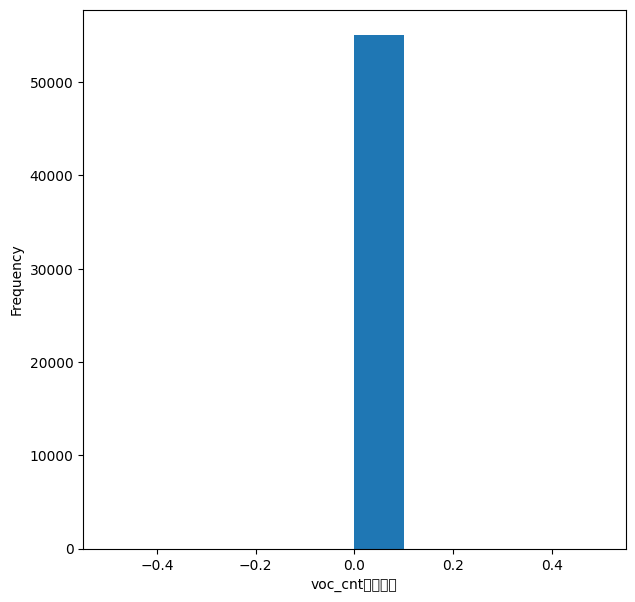

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


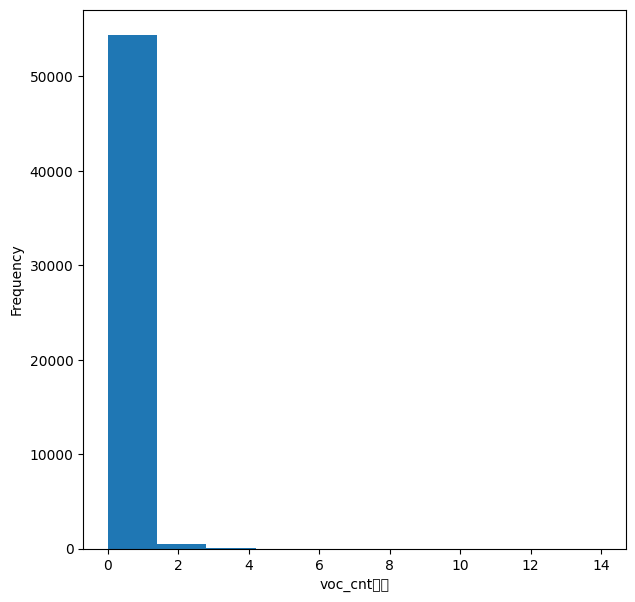

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


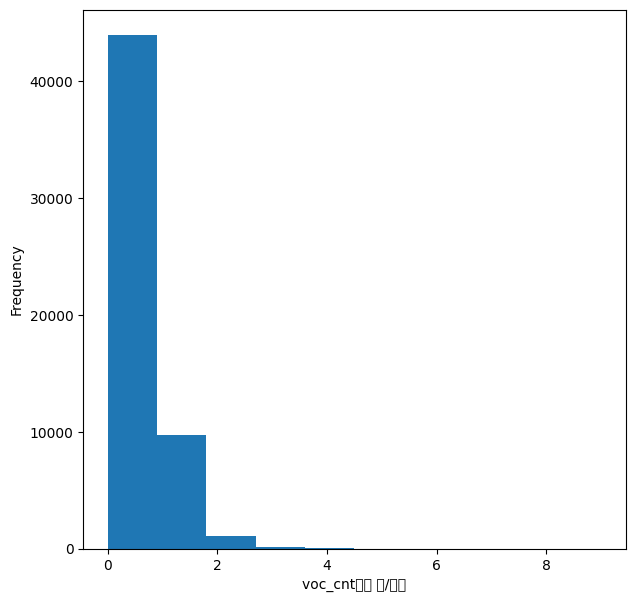

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


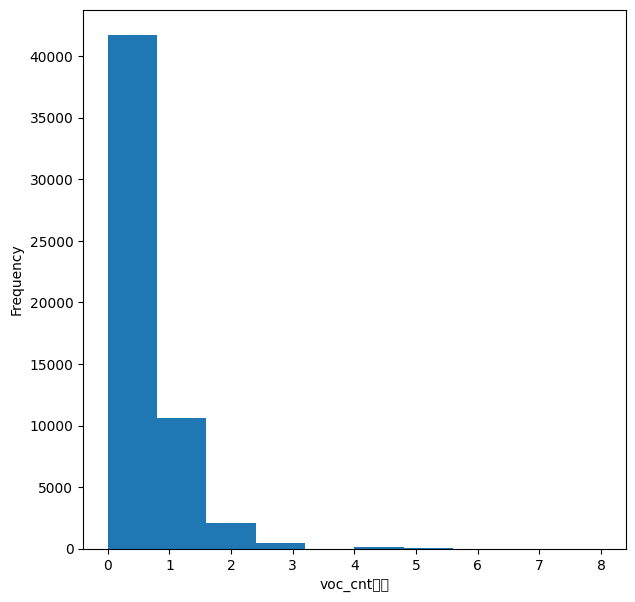

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


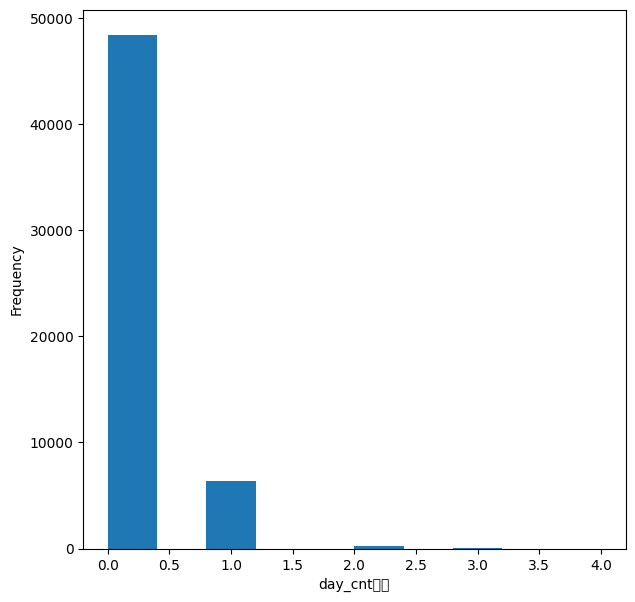

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


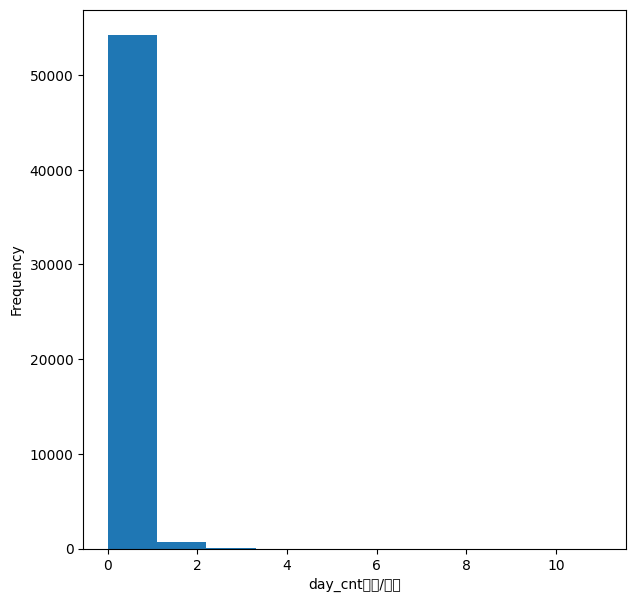

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


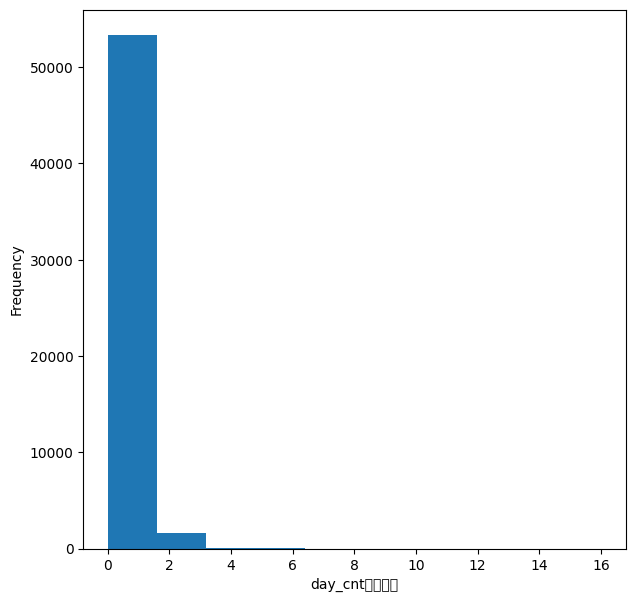

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


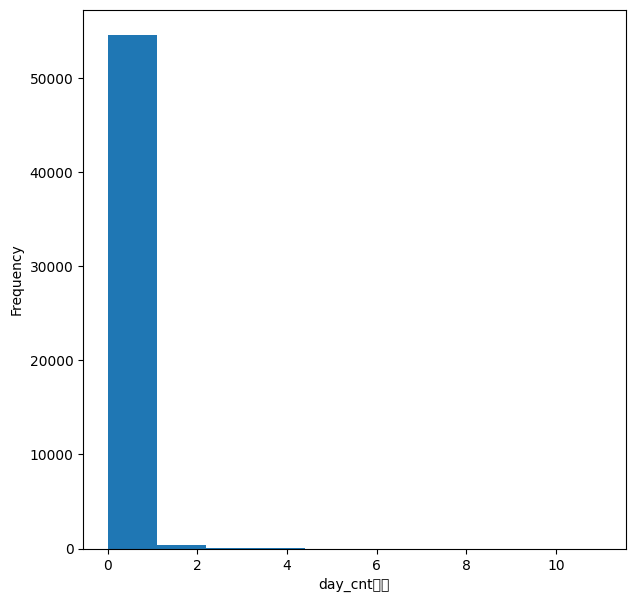

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


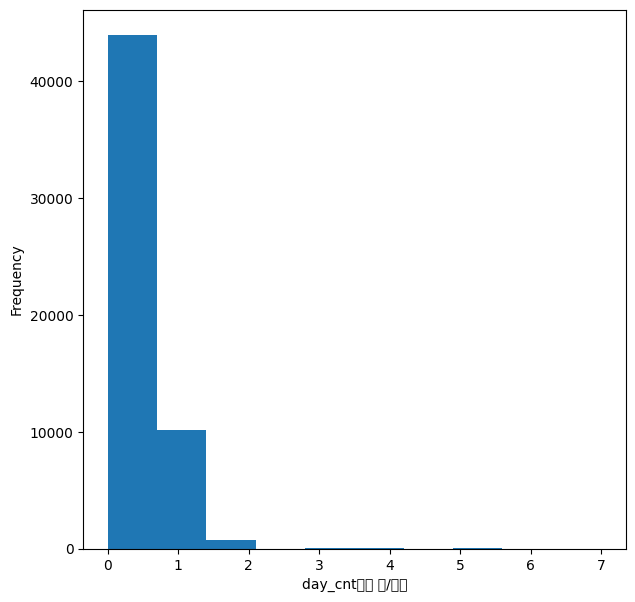

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


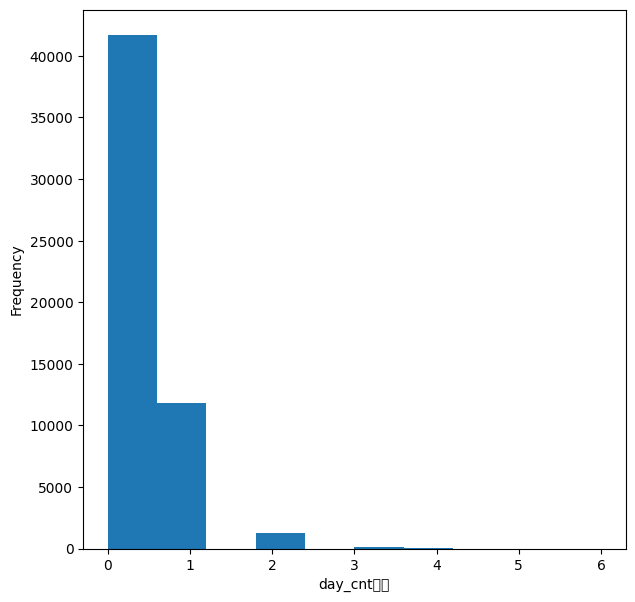

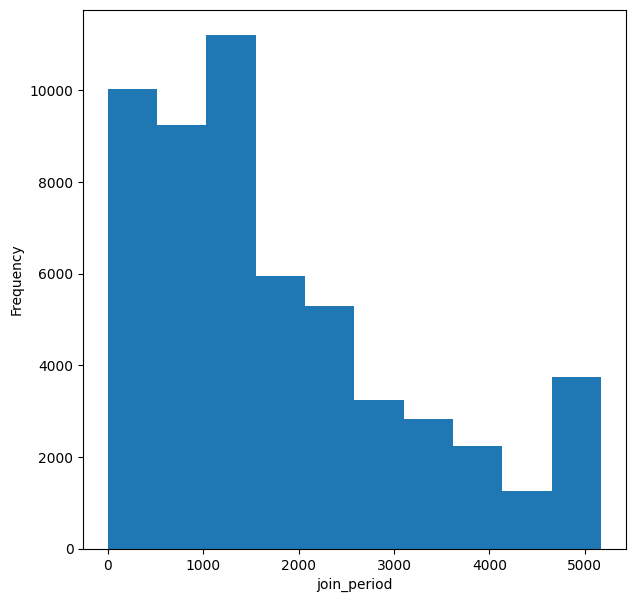

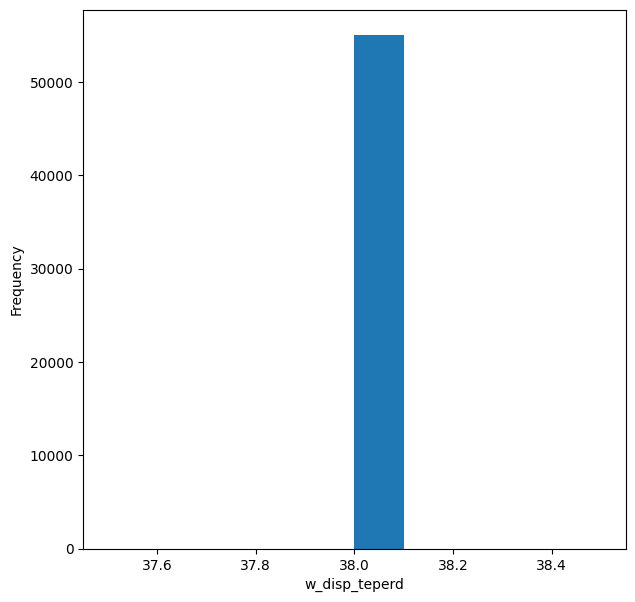

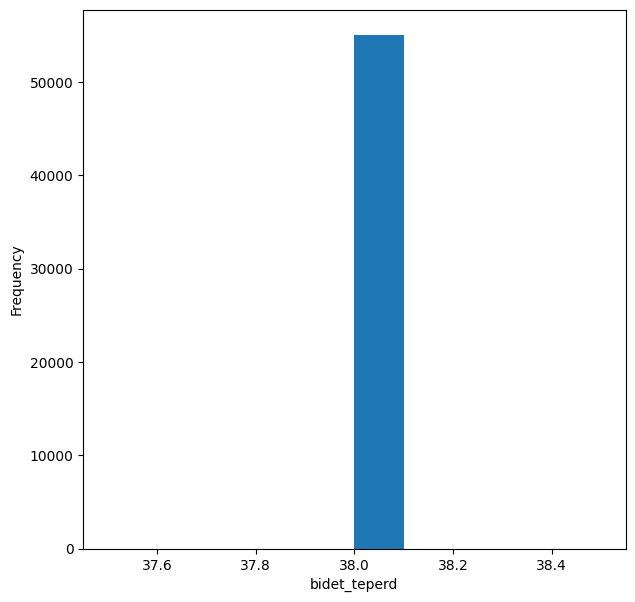

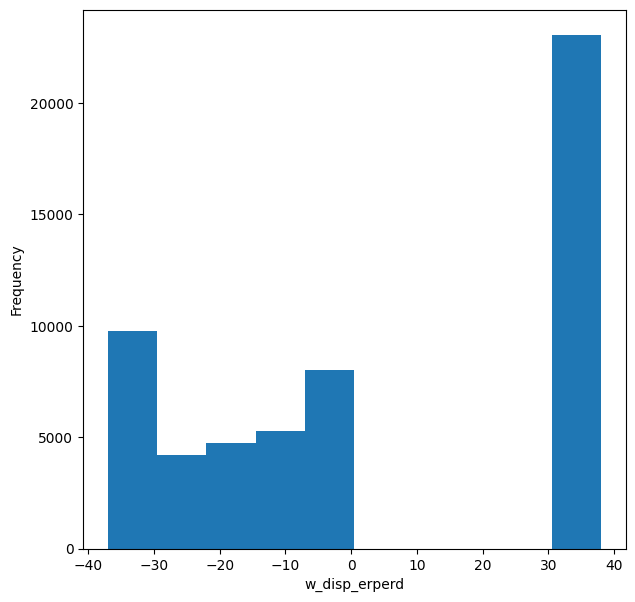

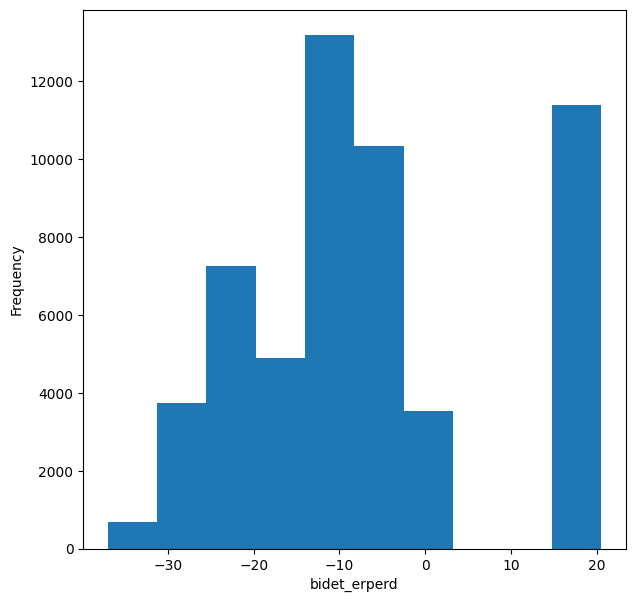

In [97]:
for cols in num_cols :
  plt.figure(figsize=(7,7))
  train_data[cols].plot(kind='hist')
  plt.xlabel(cols)
  plt.show()

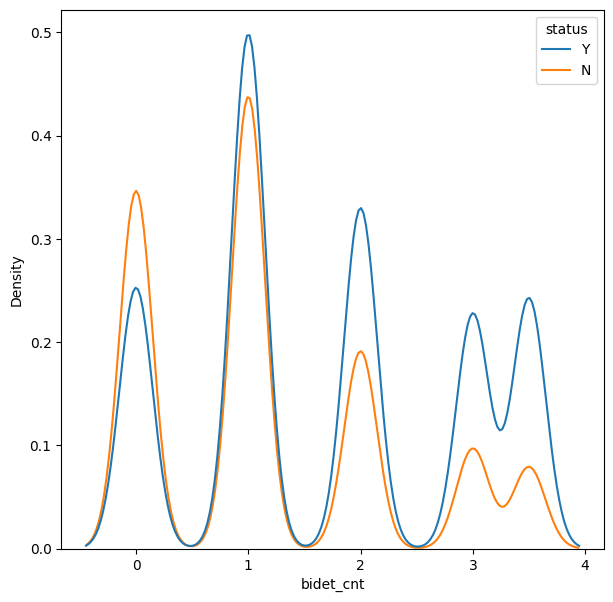

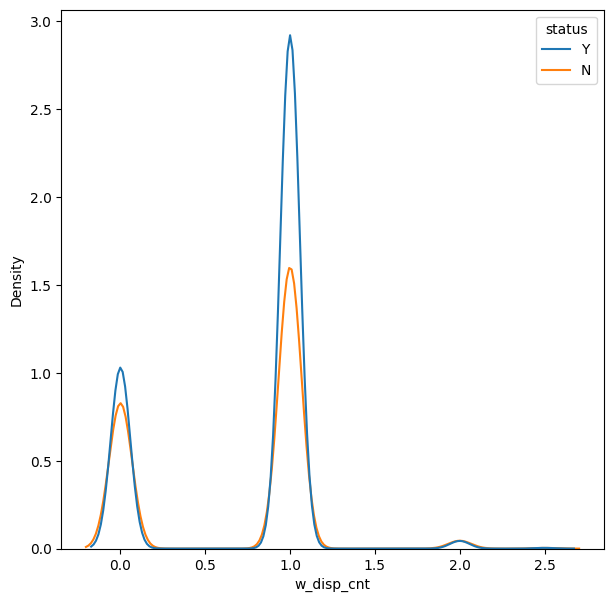

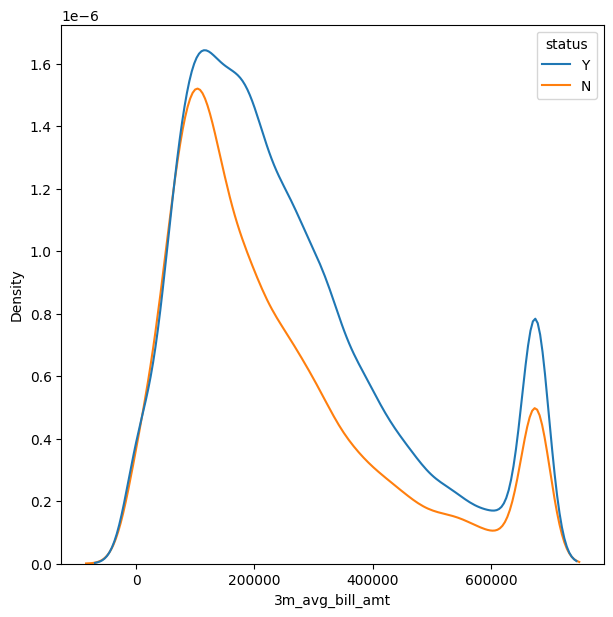

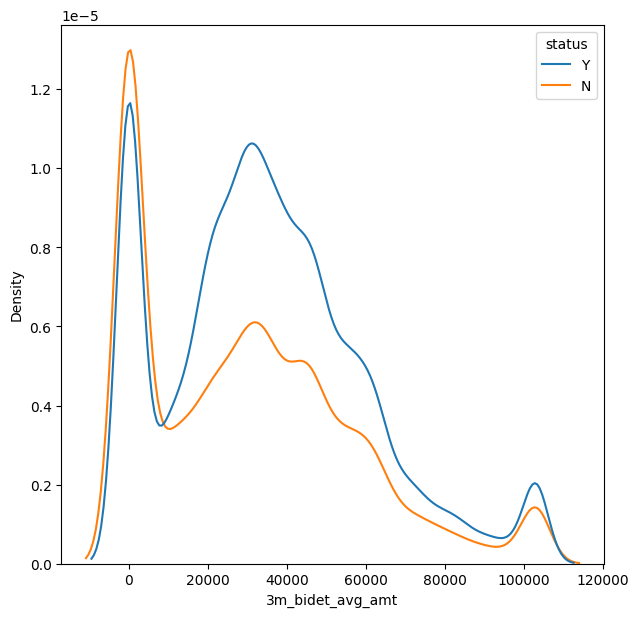

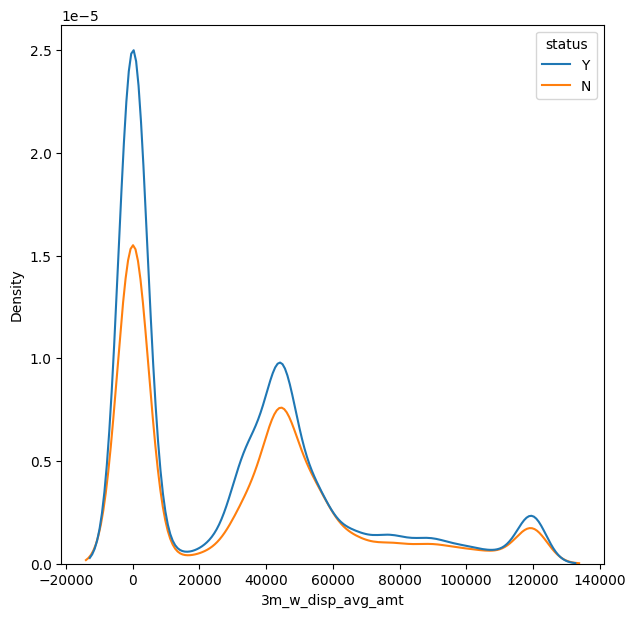

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


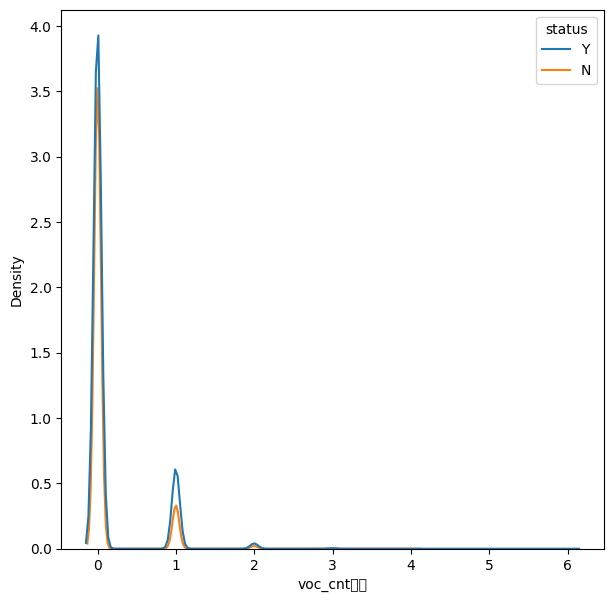

/tmp/ipykernel_1091/3545006319.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data = train_data, x = cols, hue='status')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

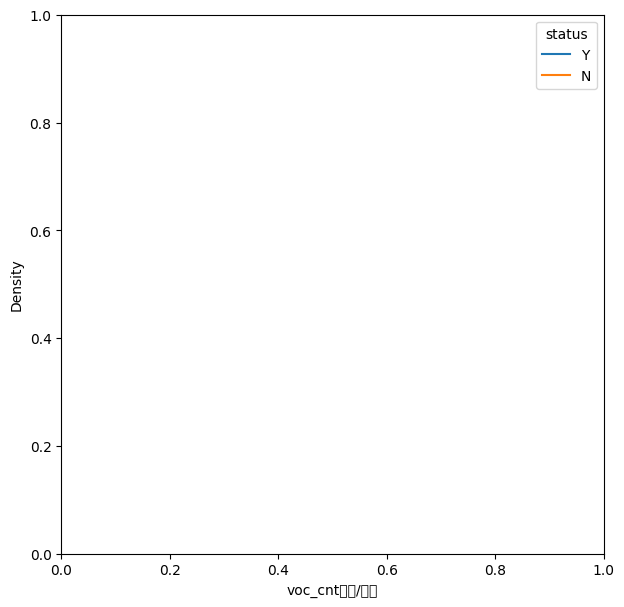

/tmp/ipykernel_1091/3545006319.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data = train_data, x = cols, hue='status')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

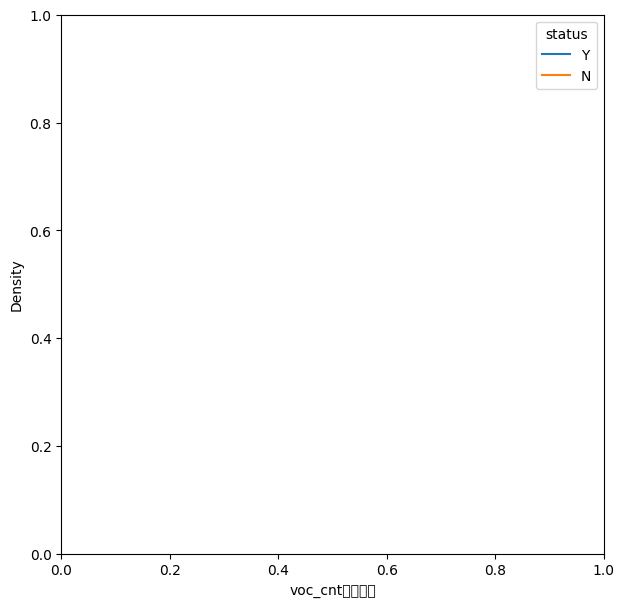

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


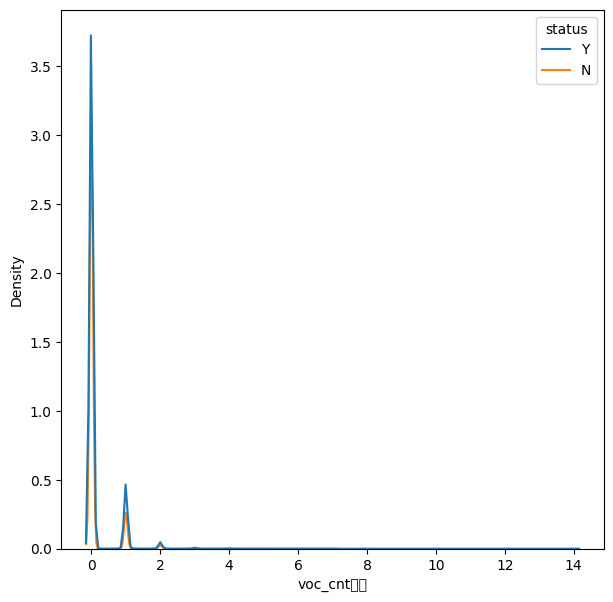

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


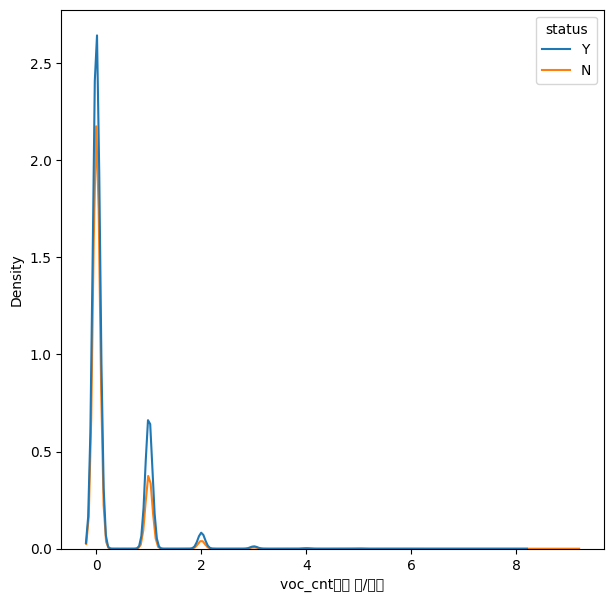

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


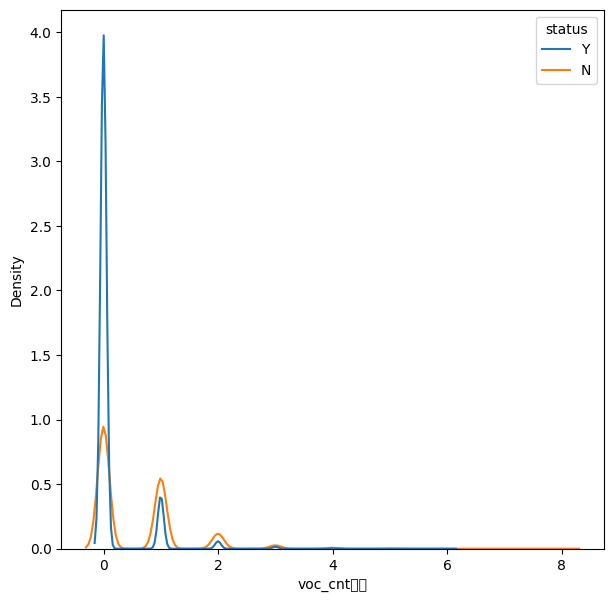

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


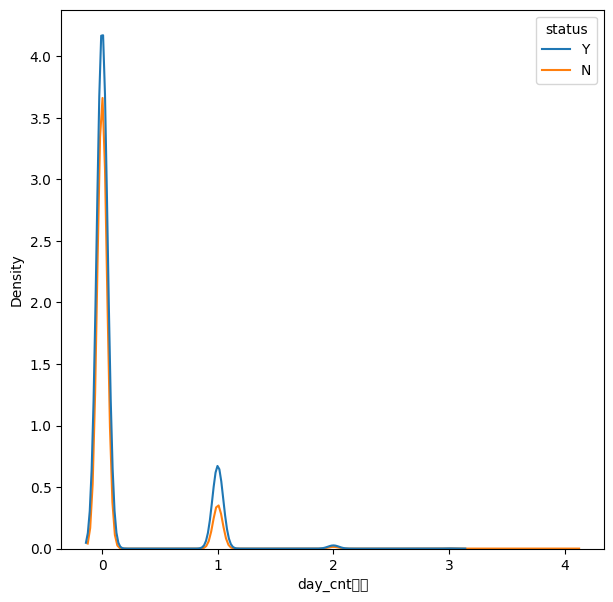

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


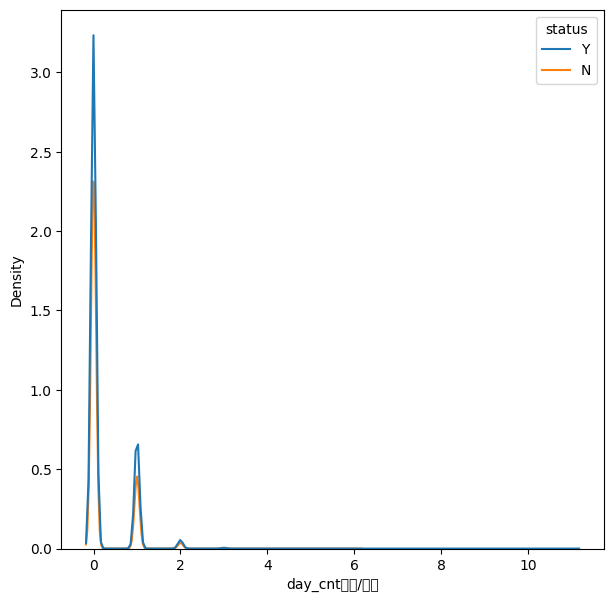

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


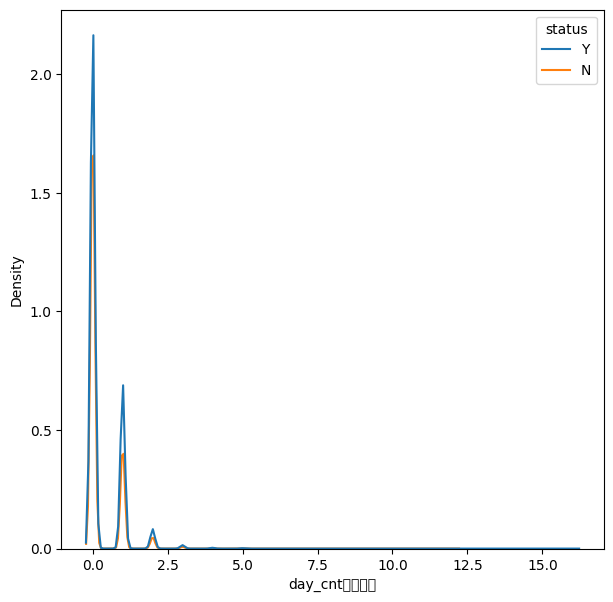

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


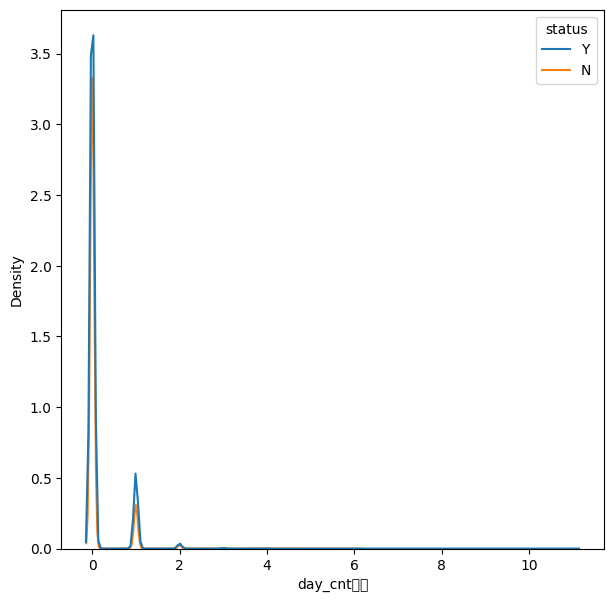

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


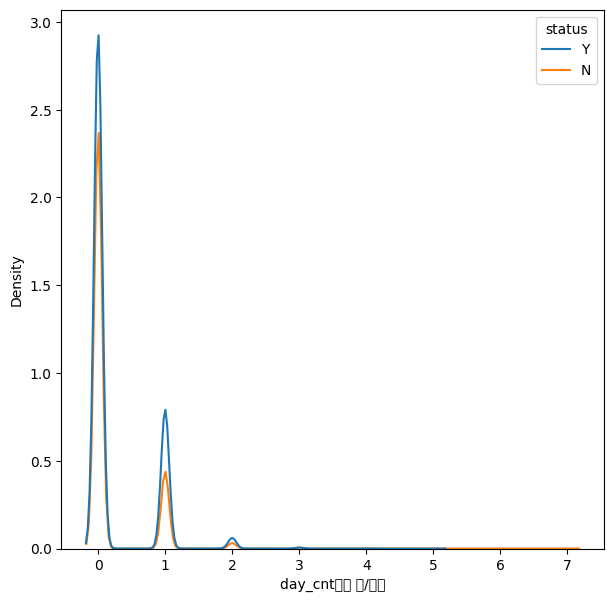

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


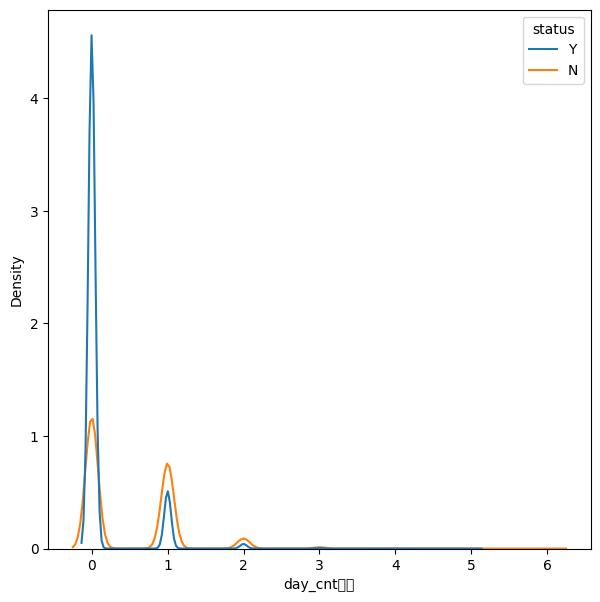

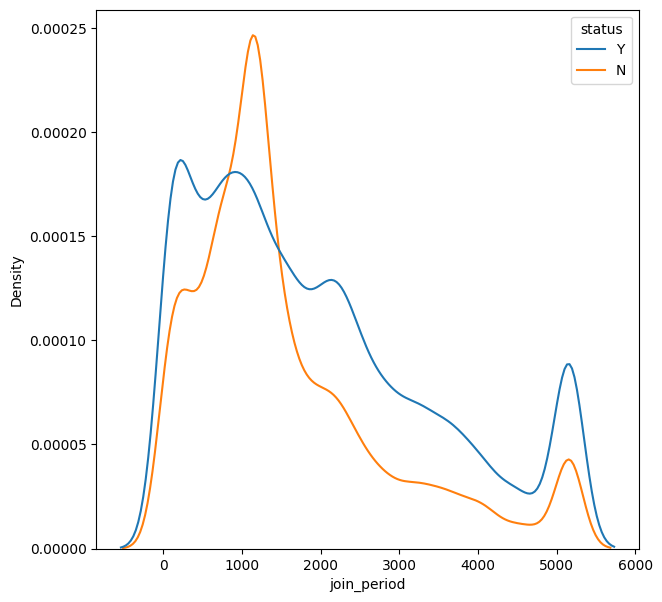

/tmp/ipykernel_1091/3545006319.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data = train_data, x = cols, hue='status')


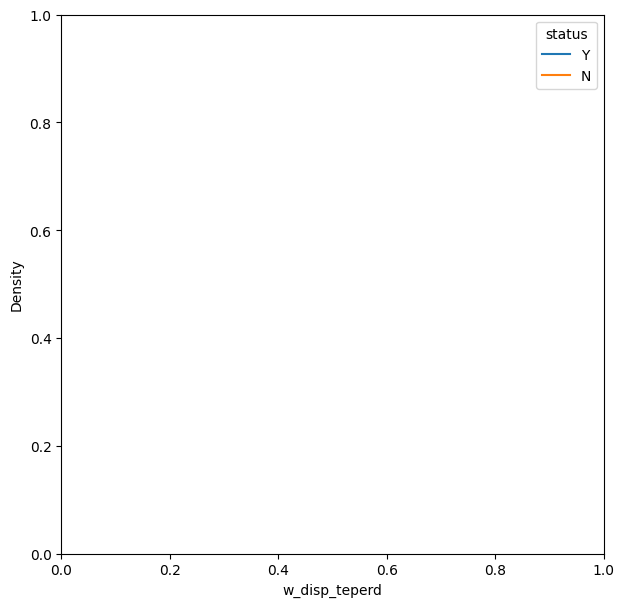

/tmp/ipykernel_1091/3545006319.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data = train_data, x = cols, hue='status')


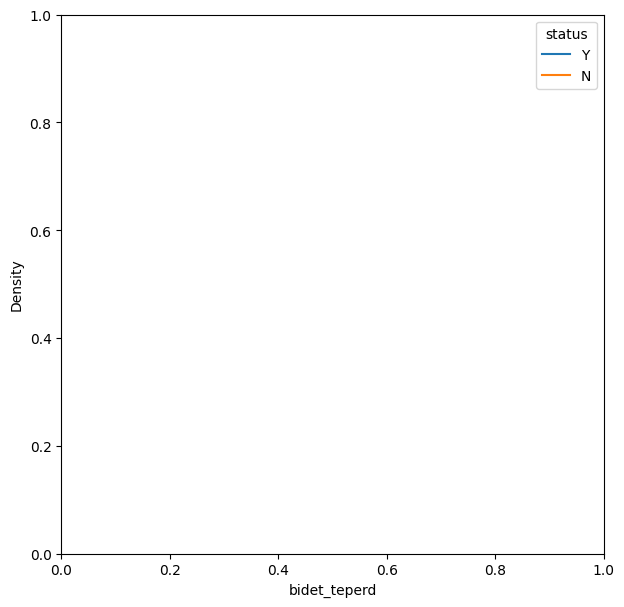

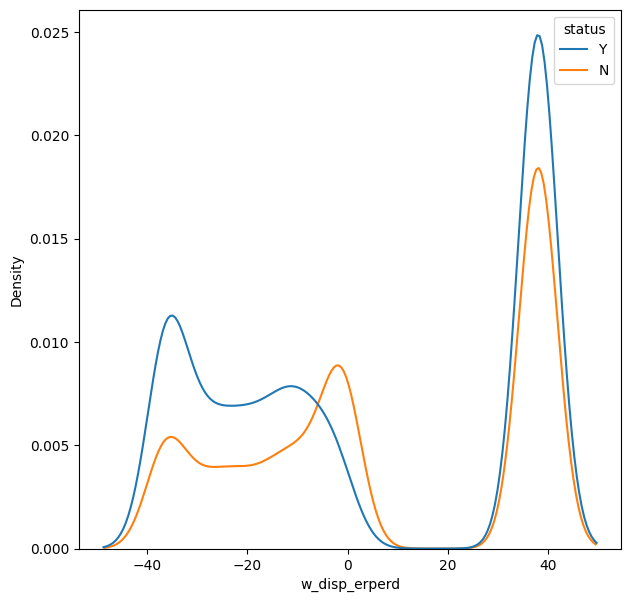

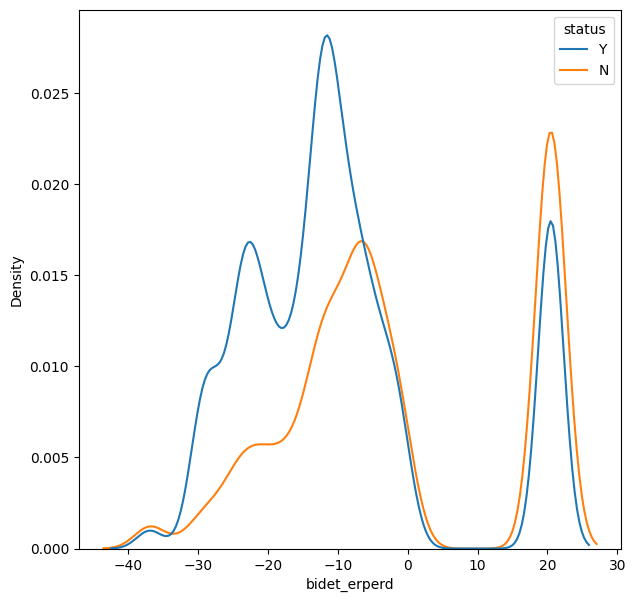

In [98]:
for cols in num_cols :
  plt.figure(figsize=(7,7))
  sns.kdeplot(data = train_data, x = cols, hue='status')
  plt.xlabel(cols)
  plt.show()



In [99]:
object_cols=train_data.select_dtypes('O').columns

In [100]:
object_cols

Index(['status', 'sex_cd', 'w_disp_yn', 'bidet_yn', 'comb_prod_yn',
       'bidet_comb_yn', 'w_disp_comb_yn', 'npay_yn'],
      dtype='object')

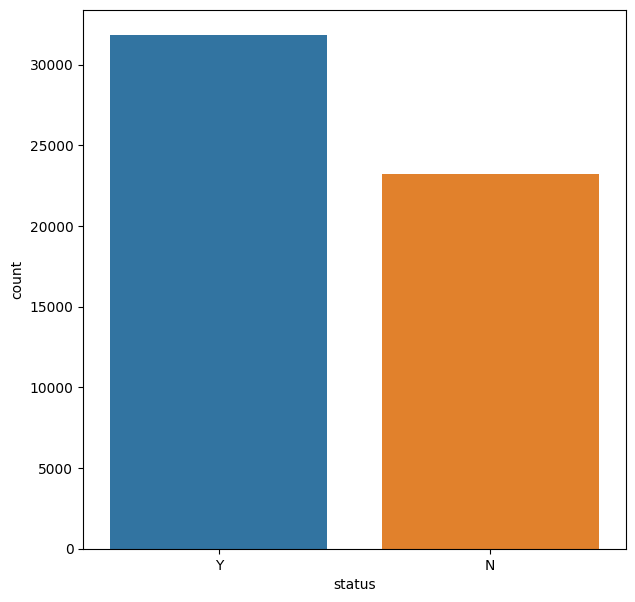

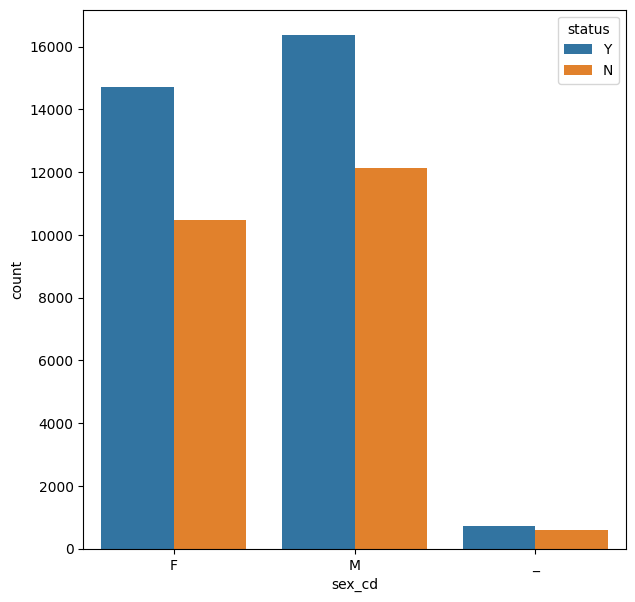

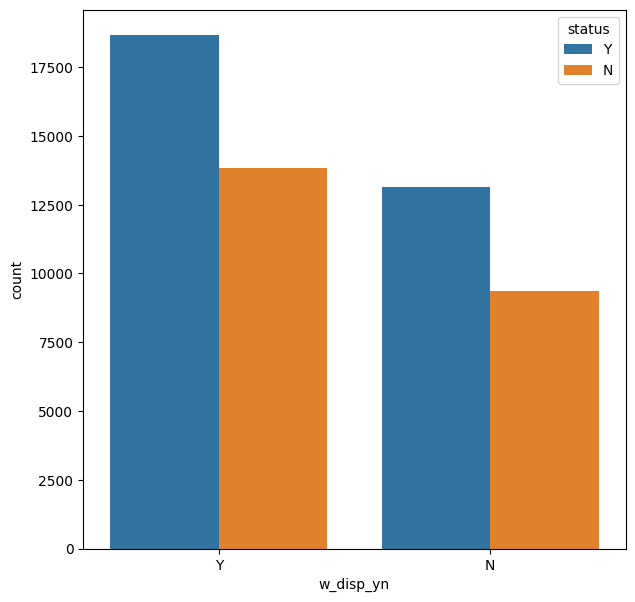

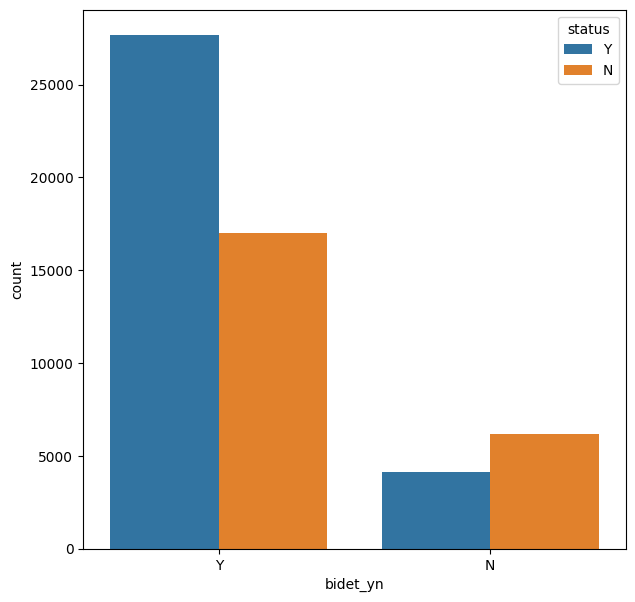

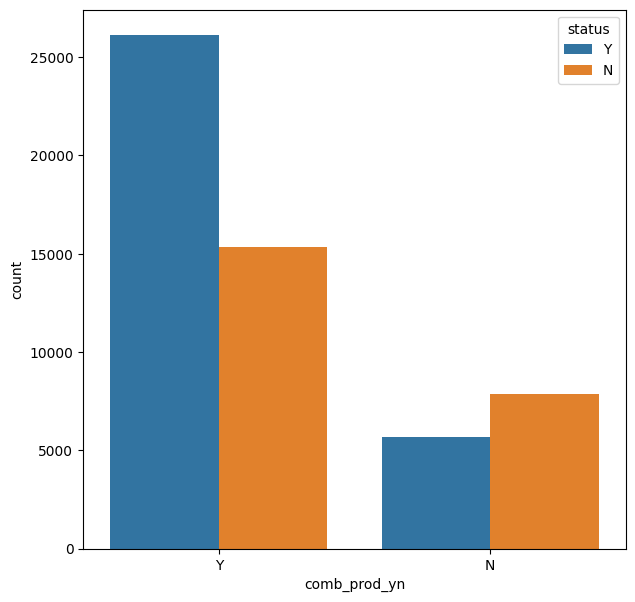

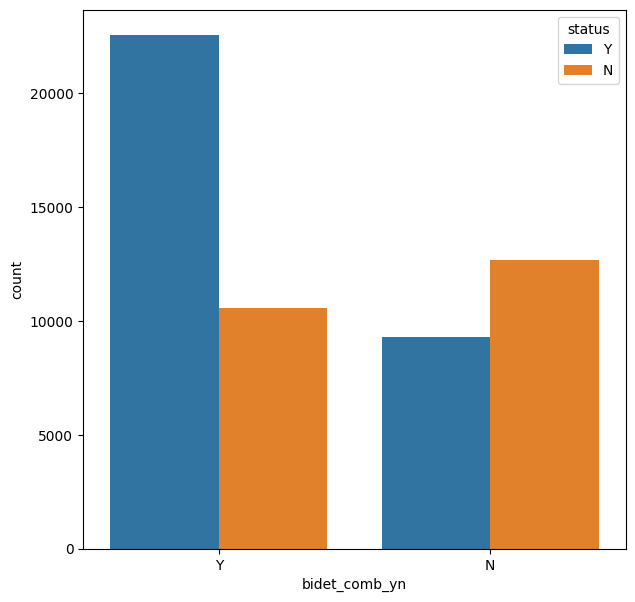

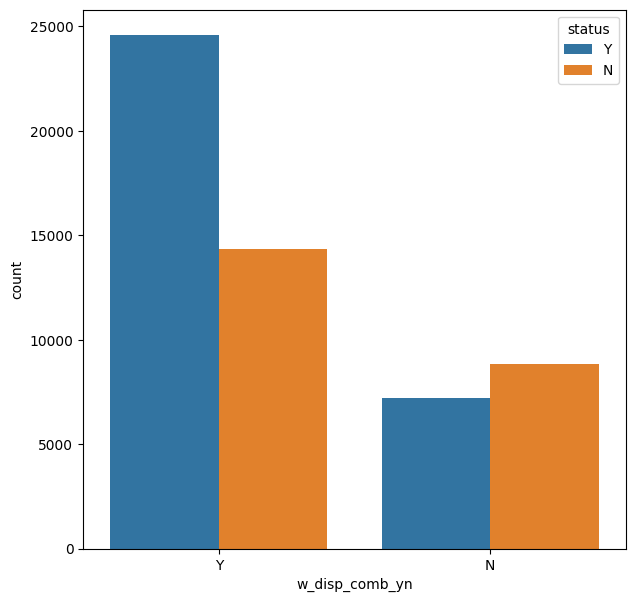

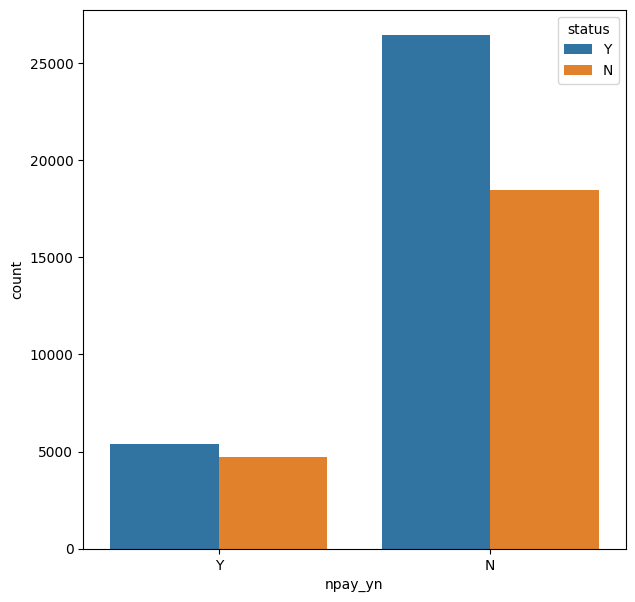

In [101]:
for cols in object_cols:
  sns.countplot(data=train_data, x = cols, hue = train_data['status'])
  plt.show()


In [102]:
number = ['int64', 'float64']
num_cols = train_data.select_dtypes(number).columns
num_cols

Index(['bidet_cnt', 'w_disp_cnt', '3m_avg_bill_amt', '3m_bidet_avg_amt',
       '3m_w_disp_avg_amt', 'voc_cnt가입', 'voc_cnt변경/조회', 'voc_cnt업무협조',
       'voc_cnt이용', 'voc_cnt청구 수/미납', 'voc_cnt해지', 'day_cnt가입', 'day_cnt변경/조회',
       'day_cnt업무협조', 'day_cnt이용', 'day_cnt청구 수/미납', 'day_cnt해지',
       'join_period', 'w_disp_teperd', 'bidet_teperd', 'w_disp_erperd',
       'bidet_erperd'],
      dtype='object')

In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


In [104]:
train_data[num_cols]=scaler.fit_transform(train_data[num_cols])

In [105]:
test_data[num_cols] = scaler.transform(test_data[num_cols])

In [106]:
round(train_data[num_cols].describe(), 3), round(test_data[num_cols], 3)

(       bidet_cnt  w_disp_cnt  3m_avg_bill_amt  3m_bidet_avg_amt  \
 count  55000.000   55000.000        55000.000         55000.000   
 mean       0.000       0.000            0.000             0.000   
 std        1.000       1.000            1.000             1.000   
 min       -1.286      -1.509           -1.430            -1.266   
 25%       -0.435      -1.509           -0.762            -0.829   
 50%       -0.435       0.570           -0.272            -0.067   
 75%        0.417       0.570            0.480             0.587   
 max        1.694       3.688            2.344             2.712   
 
        3m_w_disp_avg_amt  voc_cnt가입  voc_cnt변경/조회  voc_cnt업무협조  voc_cnt이용  \
 count          55000.000  55000.000       55000.0      55000.0  55000.000   
 mean              -0.000     -0.000           0.0          0.0      0.000   
 std                1.000      1.000           0.0          0.0      1.000   
 min               -0.901     -0.355           0.0          0.0     -0.311

In [107]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
train_data[num_cols] = mms.fit_transform(train_data[num_cols])
test_data[num_cols] = mms.transform(test_data[num_cols])
round(train_data[num_cols].describe(), 3)

,bidet_cnt,w_disp_cnt,3m_avg_bill_amt,3m_bidet_avg_amt,3m_w_disp_avg_amt,voc_cnt가입,voc_cnt변경/조회,voc_cnt업무협조,voc_cnt이용,voc_cnt청구 수/미납,...,day_cnt변경/조회,day_cnt업무협조,day_cnt이용,day_cnt청구 수/미납,day_cnt해지,join_period,w_disp_teperd,bidet_teperd,w_disp_erperd,bidet_erperd
count,55000.000,55000.000,55000.000,55000.000,55000.000,55000.000,55000.0,55000.0,55000.000,55000.000,...,55000.000,55000.000,55000.000,55000.000,55000.000,55000.000,55000.0,55000.0,55000.000,55000.000
mean,0.432,0.290,0.379,0.318,0.260,0.022,0.0,0.0,0.009,0.026,...,0.018,0.018,0.011,0.031,0.045,0.345,0.0,0.0,0.556,0.530
std,0.336,0.192,0.265,0.251,0.289,0.061,0.0,0.0,0.028,0.057,...,0.041,0.036,0.033,0.066,0.086,0.273,0.0,0.0,0.400,0.274
min,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.000
25%,0.286,0.000,0.177,0.110,0.000,0.000,0.0,0.0,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.145,0.0,0.0,0.187,0.348
50%,0.286,0.400,0.307,0.301,0.273,0.000,0.0,0.0,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.262,0.0,0.0,0.467,0.470
75%,0.571,0.400,0.506,0.466,0.400,0.000,0.0,0.0,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.487,0.0,0.0,1.000,0.609
max,1.000,1.000,1.000,1.000,1.000,1.000,0.0,0.0,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,0.0,0.0,1.000,1.000


In [108]:
le_columns = train_data.select_dtypes('O').columns
le_columns

Index(['status', 'sex_cd', 'w_disp_yn', 'bidet_yn', 'comb_prod_yn',
       'bidet_comb_yn', 'w_disp_comb_yn', 'npay_yn'],
      dtype='object')

In [109]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [110]:
for column in le_columns :
  le.fit(train_data[column])
  train_data[column] = le.transform(train_data[column])

  for label in np.unique(test_data[column]) :
    if label not in le.classes_:
      le.classes_ = np.append(le.classes_, label)

  test_data[column] = le.transform(test_data[column])

In [111]:
train_data.head()

,status,bidet_cnt,w_disp_cnt,sex_cd,w_disp_yn,bidet_yn,comb_prod_yn,bidet_comb_yn,w_disp_comb_yn,npay_yn,...,day_cnt변경/조회,day_cnt업무협조,day_cnt이용,day_cnt청구 수/미납,day_cnt해지,join_period,w_disp_teperd,bidet_teperd,w_disp_erperd,bidet_erperd
0,1,0.285714,0.0,0,1,1,1,1,1,1,...,0.0,0.0000,0.0,0.142857,0.000000,0.237501,0.0,0.0,0.373333,0.434783
1,0,0.571429,0.0,1,0,1,0,0,0,0,...,0.0,0.0000,0.0,0.000000,0.166667,0.476356,0.0,0.0,1.000000,0.539130
2,0,0.285714,0.4,1,1,0,1,1,1,0,...,0.0,0.0625,0.0,0.000000,0.000000,0.217967,0.0,0.0,0.493333,1.000000
3,1,1.000000,0.4,0,1,1,1,1,1,1,...,0.0,0.0000,0.0,0.000000,0.000000,0.771299,0.0,0.0,0.013333,0.452174
4,0,0.285714,0.4,0,1,1,1,1,1,0,...,0.0,0.0000,0.0,0.000000,0.166667,0.337492,0.0,0.0,0.133333,0.260870


In [112]:
#train_data['status'] = train_data['status'].apply(lambda x :1 if x==0 else 0)
train_data['status'] = train_data['status'].replace({1:0, 0:1})

In [113]:
test_data['status'] = test_data['status'].replace({1:0, 0:1})

In [114]:

train_data.head()

,status,bidet_cnt,w_disp_cnt,sex_cd,w_disp_yn,bidet_yn,comb_prod_yn,bidet_comb_yn,w_disp_comb_yn,npay_yn,...,day_cnt변경/조회,day_cnt업무협조,day_cnt이용,day_cnt청구 수/미납,day_cnt해지,join_period,w_disp_teperd,bidet_teperd,w_disp_erperd,bidet_erperd
0,0,0.285714,0.0,0,1,1,1,1,1,1,...,0.0,0.0000,0.0,0.142857,0.000000,0.237501,0.0,0.0,0.373333,0.434783
1,1,0.571429,0.0,1,0,1,0,0,0,0,...,0.0,0.0000,0.0,0.000000,0.166667,0.476356,0.0,0.0,1.000000,0.539130
2,1,0.285714,0.4,1,1,0,1,1,1,0,...,0.0,0.0625,0.0,0.000000,0.000000,0.217967,0.0,0.0,0.493333,1.000000
3,0,1.000000,0.4,0,1,1,1,1,1,1,...,0.0,0.0000,0.0,0.000000,0.000000,0.771299,0.0,0.0,0.013333,0.452174
4,1,0.285714,0.4,0,1,1,1,1,1,0,...,0.0,0.0000,0.0,0.000000,0.166667,0.337492,0.0,0.0,0.133333,0.260870


In [115]:
for column in le_columns :
  print(f" {column :} {train_data[column].value_counts()}")

 status status
0    31806
1    23194
Name: count, dtype: int64
 sex_cd sex_cd
1    28486
0    25178
2     1336
Name: count, dtype: int64
 w_disp_yn w_disp_yn
1    32474
0    22526
Name: count, dtype: int64
 bidet_yn bidet_yn
1    44657
0    10343
Name: count, dtype: int64
 comb_prod_yn comb_prod_yn
1    41462
0    13538
Name: count, dtype: int64
 bidet_comb_yn bidet_comb_yn
1    33075
0    21925
Name: count, dtype: int64
 w_disp_comb_yn w_disp_comb_yn
1    38924
0    16076
Name: count, dtype: int64
 npay_yn npay_yn
0    44920
1    10080
Name: count, dtype: int64


In [116]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='if_binary')
train_onehot= ohe.fit_transform(train_data[['sex_cd']])
test_onehot=ohe.transform(test_data[['sex_cd']])



In [117]:
train_onehot

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [118]:
test_onehot

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [119]:
train_data = pd.get_dummies(train_data, columns = ['sex_cd'])
train_data.head()

,status,bidet_cnt,w_disp_cnt,w_disp_yn,bidet_yn,comb_prod_yn,bidet_comb_yn,w_disp_comb_yn,npay_yn,3m_avg_bill_amt,...,day_cnt청구 수/미납,day_cnt해지,join_period,w_disp_teperd,bidet_teperd,w_disp_erperd,bidet_erperd,sex_cd_0,sex_cd_1,sex_cd_2
0,0,0.285714,0.0,1,1,1,1,1,1,0.572293,...,0.142857,0.000000,0.237501,0.0,0.0,0.373333,0.434783,True,False,False
1,1,0.571429,0.0,0,1,0,0,0,0,0.176843,...,0.000000,0.166667,0.476356,0.0,0.0,1.000000,0.539130,False,True,False
2,1,0.285714,0.4,1,0,1,1,1,0,0.147579,...,0.000000,0.000000,0.217967,0.0,0.0,0.493333,1.000000,False,True,False
3,0,1.000000,0.4,1,1,1,1,1,1,0.334380,...,0.000000,0.000000,0.771299,0.0,0.0,0.013333,0.452174,True,False,False
4,1,0.285714,0.4,1,1,1,1,1,0,0.468025,...,0.000000,0.166667,0.337492,0.0,0.0,0.133333,0.260870,True,False,False


In [120]:
test_data = pd.get_dummies(test_data, columns = ['sex_cd'])
test_data.head()

,status,bidet_cnt,w_disp_cnt,w_disp_yn,bidet_yn,comb_prod_yn,bidet_comb_yn,w_disp_comb_yn,npay_yn,3m_avg_bill_amt,...,day_cnt청구 수/미납,day_cnt해지,join_period,w_disp_teperd,bidet_teperd,w_disp_erperd,bidet_erperd,sex_cd_0,sex_cd_1,sex_cd_2
0,0,1.142857,0.4,1,1,1,1,1,0,0.267387,...,0.000000,0.0,0.232086,0.0,0.0,0.320000,0.469565,False,True,False
1,0,0.571429,0.0,0,1,1,1,0,0,2.955803,...,0.142857,0.0,0.470941,0.0,0.0,1.000000,0.643478,False,True,False
2,1,0.285714,0.0,0,1,0,0,0,0,0.126810,...,0.000000,0.0,0.212552,0.0,0.0,1.000000,0.539130,False,True,False
3,0,0.857143,0.4,1,1,1,1,1,1,0.242164,...,0.142857,0.0,0.765883,0.0,0.0,0.040000,0.400000,False,True,False
4,0,0.285714,0.0,1,1,1,1,1,0,0.536862,...,0.000000,0.0,0.332076,0.0,0.0,0.013333,0.243478,True,False,False


/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

<Axes: >

/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) miss

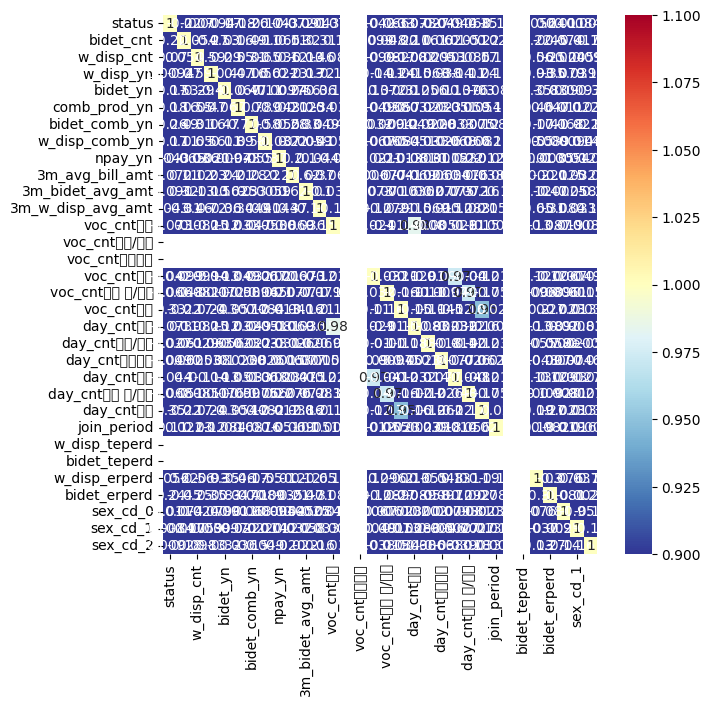

In [121]:
sns.heatmap(train_data.corr(), annot=True, cmap = 'RdYlBu_r', vmin=1, vmax=1)

In [122]:
#print(train_data.corr()>=0.9)

In [123]:
train_data.corr().index

Index(['status', 'bidet_cnt', 'w_disp_cnt', 'w_disp_yn', 'bidet_yn',
       'comb_prod_yn', 'bidet_comb_yn', 'w_disp_comb_yn', 'npay_yn',
       '3m_avg_bill_amt', '3m_bidet_avg_amt', '3m_w_disp_avg_amt', 'voc_cnt가입',
       'voc_cnt변경/조회', 'voc_cnt업무협조', 'voc_cnt이용', 'voc_cnt청구 수/미납',
       'voc_cnt해지', 'day_cnt가입', 'day_cnt변경/조회', 'day_cnt업무협조', 'day_cnt이용',
       'day_cnt청구 수/미납', 'day_cnt해지', 'join_period', 'w_disp_teperd',
       'bidet_teperd', 'w_disp_erperd', 'bidet_erperd', 'sex_cd_0', 'sex_cd_1',
       'sex_cd_2'],
      dtype='object')

In [124]:
check=[]
mcol_linearity=[]

train_corr = train_data.corr()

for idx in train_corr.index :

  check.append(idx)
  for column in train_corr.columns :

      if column not in check :
         if (train_corr.loc[idx, column] >=0.9 and
             train_corr.loc[idx, column] <1) or (train_corr.loc[idx, column] <=-0.9 and
             train_corr.loc[idx, column]>-1):
                mcol_linearity.append([idx, column])

mcol_linearity

[['w_disp_yn', 'w_disp_erperd'],
 ['voc_cnt가입', 'day_cnt가입'],
 ['voc_cnt이용', 'day_cnt이용'],
 ['voc_cnt청구 수/미납', 'day_cnt청구 수/미납'],
 ['voc_cnt해지', 'day_cnt해지'],
 ['sex_cd_0', 'sex_cd_1']]

In [125]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['VIF_Factor'] = [variance_inflation_factor(train_data.values, i) for i in tqdm(range(train_data.shape[1]))]
vif['Feature'] = train_data.columns
vif = vif.sort_values(by = 'VIF_Factor', ascending = False).reset_index().drop(columns='index')
vif

  0%|          | 0/32 [00:00<?, ?it/s]/tmp/ipykernel_1091/4057906304.py:5: UserWarning: The design matrix is poorly conditioned (condition number=2.57e+19). VIF calculations may be numerically unstable.
  vif['VIF_Factor'] = [variance_inflation_factor(train_data.values, i) for i in tqdm(range(train_data.shape[1]))]
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
  3%|▎         | 1/32 [00:00<00:14,  2.07it/s]/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
  6%|▋         | 2/32 [00:00<00:14,  2.06it/s]/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design 

,VIF_Factor,Feature
0,1.000800e+15,sex_cd_0
1,1.000800e+15,sex_cd_1
2,1.000800e+15,sex_cd_2
3,3.014968e+01,day_cnt가입
4,2.999316e+01,voc_cnt가입
5,1.908110e+01,day_cnt이용
6,1.900802e+01,voc_cnt이용
7,1.786603e+01,day_cnt청구 수/미납
8,1.767021e+01,voc_cnt청구 수/미납
9,1.015342e+01,day_cnt해지


In [126]:
del_cols=['sex_cd_1', 'voc_cnt가입','voc_cnt이용', 'voc_cnt청구 수/미납', 'voc_cnt해지']

train_data = train_data.drop(del_cols, axis=1)
test_data = test_data.drop(del_cols, axis=1)

In [127]:
train_data.columns

Index(['status', 'bidet_cnt', 'w_disp_cnt', 'w_disp_yn', 'bidet_yn',
       'comb_prod_yn', 'bidet_comb_yn', 'w_disp_comb_yn', 'npay_yn',
       '3m_avg_bill_amt', '3m_bidet_avg_amt', '3m_w_disp_avg_amt',
       'voc_cnt변경/조회', 'voc_cnt업무협조', 'day_cnt가입', 'day_cnt변경/조회',
       'day_cnt업무협조', 'day_cnt이용', 'day_cnt청구 수/미납', 'day_cnt해지',
       'join_period', 'w_disp_teperd', 'bidet_teperd', 'w_disp_erperd',
       'bidet_erperd', 'sex_cd_0', 'sex_cd_2'],
      dtype='object')

In [128]:
from sklearn.model_selection import train_test_split

tts = train_test_split
x_train, x_val, y_train, y_val = tts(train_data.drop(columns = 'status'), train_data['status'],
                                     random_state =  10, stratify = train_data['status'])

x_train.shape, x_val.shape, y_train.shape, y_val.shape

((41250, 26), (13750, 26), (41250,), (13750,))

In [129]:
x_test = test_data.drop(columns = 'status')
y_test = test_data['status']

x_test.shape, y_test.shape

((5000, 26), (5000,))

In [130]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

result = pd.DataFrame([], columns=['acc', 'recall', 'precision', 'F1_score'])

def result_view(model_name, pred, actual):
  acc = round(accuracy_score(actual, pred), 3)
  precision = round(precision_score(actual, pred), 3)
  recall = round(recall_score(actual, pred), 3)
  F1 = round(f1_score(actual, pred), 3)

  result.loc[model_name] = (acc, recall, precision, F1)
  result.sort_values(by='acc', inplace=True, ascending=False)

  print(result)

  plt.figure()

  for idx in result.index :
    x_values = result.columns
    y_values = result.loc[idx]
    plt.plot(x_values, y_values)
  plt.legend(result.index)
  plt.show()

In [131]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42)

model_lr.fit(x_train, y_train)

LogisticRegression(random_state=42)

            acc  recall  precision  F1_score
model_lr  0.708   0.602      0.662     0.631


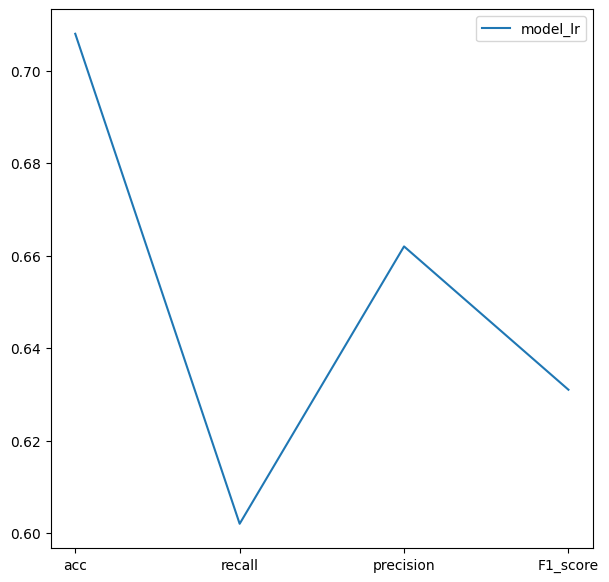

In [132]:
pred_lr=model_lr.predict(x_test)
result_view('model_lr', pred_lr, y_test)

In [133]:
from sklearn.neighbors import KNeighborsClassifier

KNN = KNeighborsClassifier()

KNN.fit(x_train, y_train)

KNeighborsClassifier()

            acc  recall  precision  F1_score
model_lr  0.708   0.602      0.662     0.631
KNN       0.678   0.548      0.626     0.585


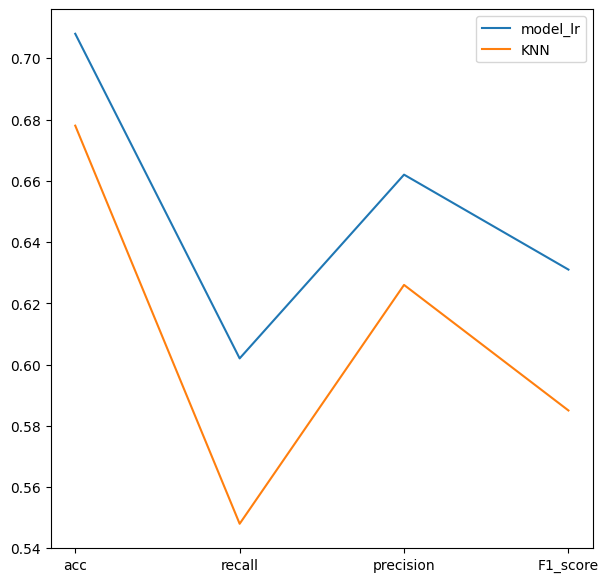

In [134]:
pred_knn = KNN.predict(x_test)
result_view('KNN', pred_knn,y_test)

            acc  recall  precision  F1_score
model_lr  0.708   0.602      0.662     0.631
SVM       0.696   0.460      0.704     0.557
KNN       0.678   0.548      0.626     0.585


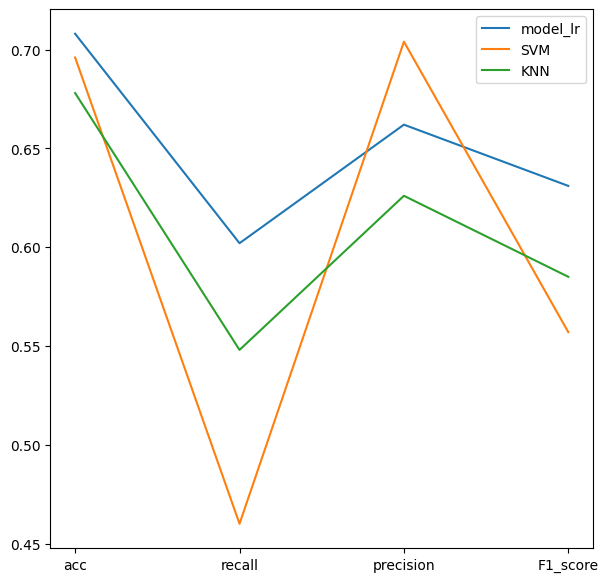

In [138]:
from sklearn.svm import SVC
SVM = SVC(random_state = 42)
SVM.fit(x_train, y_train)
pred_SVM = SVM.predict(x_test)
result_view('SVM', pred_SVM, y_test)

            acc  recall  precision  F1_score
dtc       0.709   0.581      0.671     0.623
model_lr  0.708   0.602      0.662     0.631
SVM       0.696   0.460      0.704     0.557
KNN       0.678   0.548      0.626     0.585


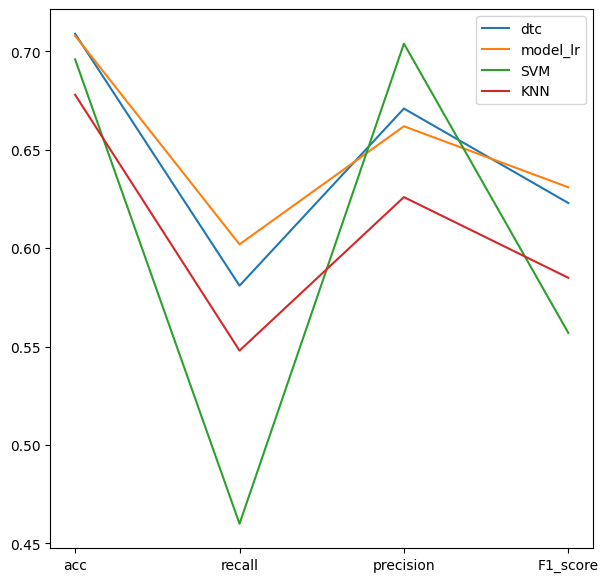

In [139]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(min_samples_split=2, min_samples_leaf=1,
                             max_features=None, max_depth=5,
                             max_leaf_nodes = None, random_state = 42)

dtc.fit(x_train, y_train)
pred_dtc = dtc.predict(x_test)

result_view('dtc', pred_dtc, y_test)

            acc  recall  precision  F1_score
dtc       0.709   0.581      0.671     0.623
rfc       0.709   0.581      0.672     0.623
model_lr  0.708   0.602      0.662     0.631
SVM       0.696   0.460      0.704     0.557
KNN       0.678   0.548      0.626     0.585


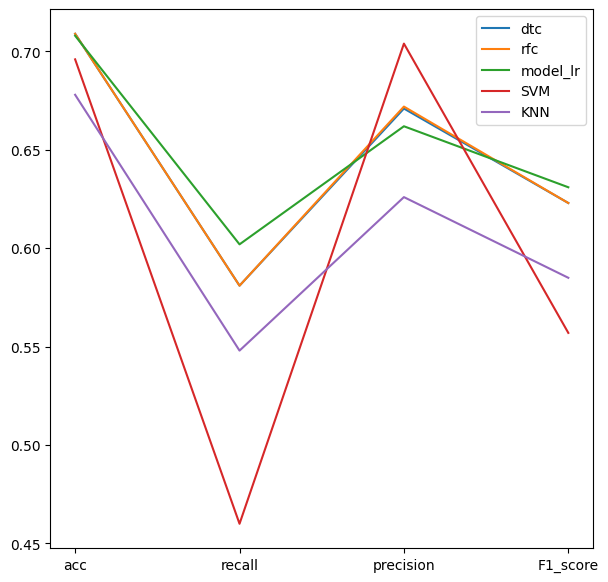

In [144]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_jobs=-1, n_estimators=100,
                             min_samples_split = 2,
                             min_samples_leaf=1,
                             max_features=None,
                             max_depth=None,
                             max_leaf_nodes=None,
                             random_state=42)

rfc.fit(x_train, y_train)
pred_rfc=rfc.predict(x_test)
result_view('rfc', pred_rfc, y_test)